# Private Fund Holdings — Data-State Analysis

**Objective 1 (Data-State Analysis).**

Goal: produce a completeness and cleanliness scorecard across all major dimensions, including by
field, by fund, and by manager, that quantifies where gaps concentrate and identifies the most
impactful categories of missing or inconsistent data. Success is measured by coverage: every major
field in the CSV must be assessed, and findings must be clear enough for the operations team to
prioritize remediation.

Method summary:
1. **Load and inspect** the raw extract; establish the grain; drop attributes that carry no information
2. **Check identifier integrity** so fund and manager rollups are trustworthy (Section 3.1)
3. **Exclude non-investment items** so completeness reflects real portfolio companies
4. **Score by field** — overall fill rates and key-field breakdown by category
5. **Score by fund** — which funds report the least
6. **Score by manager** — which GPs report the least across all their funds
7. **Apply conditional expectations** so a blank that is *supposed* to be blank is not a defect (Section 7.1)
8. **Entity resolution scope** — the true near-duplicate backlog, not the already-matched set
9. **Reporting gaps** measured on each fund's own reporting calendar (Section 10.1)
10. **Cross-field consistency and validity checks** — the cleanliness half of the objective (Section 16.1)
11. **Export** flagged records and a consolidated data-state summary for Operations

**Terminology.** Sections 5 to 7 report a *fill rate*: the share of non-null values, scored
unconditionally. Section 7.1 converts that into a *conditional completeness score*, which is the
number Operations should act on. The two are deliberately kept separate so the effect of the
conditional rules is visible.

**Scope caveat for the sponsor.** This notebook measures the state of the vendor CSV. It cannot
distinguish "the GP did not report the field" from "the vendor failed to extract it". That
distinction requires the Phase 2 PDF spot-check, and every manager-attributed finding below should
be read as a hypothesis until then.

### 1. Imports and parameters

Following discussions with the Brown Investment Office, we confirmed that the following fields are the mandatory attributes for evaluating data quality. These attributes are grouped into two primary categories.

**1. Investment Metrics (Cost, Value, and Proceeds)**

* Capital Invested
* Current Cost
* Unrealized Value
* Realized Proceeds

**2. Portfolio Company Information**

* Deal Status
* Sector
* Geography
* Public vs. Private Classification


In [1]:
# --- Tunable parameters ---
from pathlib import Path

# Resolve paths relative to this notebook so the run does not depend on the
# working directory the editor happens to launch the kernel in.
BASE      = Path.cwd()
DATA_DIR  = (BASE / '..' / 'data').resolve()      # read-only: vendor extract
REPORTS   = (BASE / '..' / 'reports').resolve()   # everything reproducible

REPORTS.mkdir(parents=True, exist_ok=True)
assert DATA_DIR.is_dir(), f'data directory not found: {DATA_DIR}'

MIN_ROWS_PER_GROUP = 10      # groups below this are reported as low-evidence, never ranked
FILL_THRESHOLD     = 0.85    # reference line used in completeness charts
MIN_ROWS_PER_MANAGER = MIN_ROWS_PER_GROUP   # kept for backwards compatibility

# Fields treated as mandatory when scoring a fund or a manager.
# NOTE: this list is scored unconditionally in Sections 5-7 (a fill rate).
# Section 7.2 applies the sponsor's conditional expectations on top of it.
# Confirmed with the Investment Office as the 8th mandatory field: Public/Private
# Classification. There is no directly-reported field for it; it is derived from
# Type of Investment in Section 4.1, immediately after Source Asset classification.
MANDATORY = [
    'Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds',
    'Deal Status', 'Sector', 'Geographic Focus', 'Public/Private Classification',
]

# Type of Investment values that count as a company (as opposed to Real Estate,
# Fund, Cryptocurrency, Financial Asset, Infrastructure, Natural Resources, Other).
# Public/Private Classification is only applicable on these; see Section 7.2.
COMPANY_TYPES = {'Public Company', 'Private Company'}

# Force ID columns as strings to avoid scientific-notation corruption on read.
# This cannot repair IDs already written in scientific notation upstream;
# Section 3.1 quantifies those.
ID_DTYPES = {
    'Investment Manager Allocator ID': 'string',
    'Fund Allocator ID': 'string',
    'Source Asset ID': 'string',
    'Instrument ID': 'string',
    'Allocator Asset Allocator ID': 'string',
}

# Observed identifier shape in this extract: one letter/digit prefix + 6 hex chars.
ID_PATTERN = r'^[0-9A-Za-z]{6,8}$'

print(f'data dir         : {DATA_DIR}')
print(f'reports dir      : {REPORTS}')
print(f'Mandatory fields : {MANDATORY}')
print(f'Fill threshold   : {FILL_THRESHOLD:.0%}')
print(f'Min rows/group   : {MIN_ROWS_PER_GROUP}')

data dir         : /sessions/determined-jolly-meitner/mnt/DATA2050_Capstone/FundHoldings/data
reports dir      : /sessions/determined-jolly-meitner/mnt/DATA2050_Capstone/FundHoldings/reports
Mandatory fields : ['Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds', 'Deal Status', 'Sector', 'Geographic Focus', 'Public/Private Classification']
Fill threshold   : 85%
Min rows/group   : 10


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import source_asset_filter as saf

df = pd.read_csv(
    DATA_DIR / 'holdings_anonymized.csv',
    low_memory=False,
    dtype=ID_DTYPES,
)
print(df.shape)
print(df.columns)
df.head()

(58160, 837)
Index(['Investment Manager Allocator ID', 'Fund Allocator ID', 'Source Asset',
       'Source Asset ID', 'Is Instrument', 'Instrument Name', 'Instrument ID',
       'As At Date', 'Deal Status', 'Asset Status',
       ...
       'Latest/Exit EBITDA Multiple', 'Latest/Exit EBITDA Multiple Unit',
       'Latest/Exit Pro Forma EBITDA Multiple',
       'Latest/Exit Pro Forma EBITDA Multiple Unit',
       'Latest/Exit Adjusted EBITDA Multiple',
       'Latest/Exit Adjusted EBITDA Multiple Unit',
       'Latest/Exit Net Debt Multiple', 'Latest/Exit Net Debt Multiple Unit',
       'Latest/Exit Debt Multiple', 'Latest/Exit Debt Multiple Unit'],
      dtype='object', length=837)


,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,Is Instrument,Instrument Name,Instrument ID,As At Date,Deal Status,Asset Status,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit
0,Afc0dbf,Aa967c0,"8000 Tartak Street Owner LLC (""Embassy Suites"")",Add4554,NaN,NaN,<NA>,31-Mar-26,Current,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afc0dbf,Aa967c0,Non-Investment Assets - Cash,A047cfd,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afc0dbf,Aa967c0,Non-Investment Assets - Other Assets,A21dc07,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afc0dbf,Aa967c0,Non-Investment Liabilities - Other Liabilities,A4f93a9,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A664a6a,Ad52755,Non-Investment Assets - Cash,489269,NaN,NaN,<NA>,31-Mar-26,NaN,Existing Asset,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Data import and inspection

The extract covers six reporting dates from Q4 2024 to Q1 2026. All six fall on quarter ends, the fund reports  quarterly, semi-annual and annual cycles, and a fund on an annual cycle will simply appear on the December dates only.
Section 10.1 infers each fund's cadence before drawing any conclusion about missing periods.

In [3]:
# Reporting calendar actually present in the extract.
# The sponsor documents quarterly, semi-annual AND annual reporting cycles,
# so a fund is not expected to appear on every date below. Section 10.1
# builds each fund's own calendar before measuring reporting gaps.
print('Distinct As At Date values:')
print(sorted(df['As At Date'].unique()))
print(f'\nReporting currencies: {df["Reporting Currency"].dropna().unique()}')

Distinct As At Date values:
['30-Jun-25', '30-Sep-25', '31-Dec-24', '31-Dec-25', '31-Mar-25', '31-Mar-26']

Reporting currencies: ['SEK' 'NOK' 'DKK' 'EUR' 'USD' 'GBP' 'AUD' 'CAD' '$' 'C$' 'US$']


All six dates are quarter ends. Whether an individual fund reports on all of them is established
per fund in Section 10.1, not assumed here.

### 3. Attribute-level missingness

In [4]:
missing = pd.DataFrame({'missing_cnt': df.isnull().sum(), 
                       'missing_pnt': df.isnull().mean()*100}).sort_values('missing_pnt', ascending=False)
missing[missing['missing_cnt'] > 0]

,missing_cnt,missing_pnt
Projected QTD EBIT Unit,58160,100.000000
Maturity Date Unit,58160,100.000000
Projected Adjusted LTM EBITA YoY % Change Unit,58160,100.000000
Frequency Unit,58160,100.000000
Projected Adjusted LTM EBITA 3 Year CAGR,58160,100.000000
...,...,...
Sector,129,0.221802
Sector Level 1,129,0.221802
Geographic Focus,31,0.053301
Geography Level 1,31,0.053301


In [5]:
missing['missing_pnt'].value_counts().sort_index()

missing_pnt
0.000000        7
0.001719        1
0.053301        2
0.221802        2
0.775447        1
             ... 
99.993122       8
99.994842      16
99.996561      12
99.998281      29
100.000000    249
Name: count, Length: 238, dtype: int64

Only 7 attributes are 100% complete and 249 are 100% empty. The empty ones are dropped, since a
column with no values anywhere cannot be scored and would only dilute the field-level summary.
Note that this drop happens before the non-investment rows are removed, so the later statement
that no scored column is completely empty follows from this step, not from the row filter.

In [6]:
df_clean = df.dropna(axis=1, how='all').copy()
df.shape[1] - df_clean.shape[1]

249

In [7]:
# A full-row duplicate check across 837 columns is close to vacuous: any single
# differing float makes a row unique. The meaningful test for a panel extract is
# the grain, i.e. what makes one row unique.
GRAIN_CANDIDATES = [
    ['Fund Allocator ID', 'Source Asset ID', 'As At Date'],
    ['Fund Allocator ID', 'Source Asset ID', 'Instrument ID', 'As At Date'],
]

print(f'Exact full-row duplicates: {df.duplicated().sum():,}  (weak test)\n')
for key in GRAIN_CANDIDATES:
    dup = df.duplicated(subset=key, keep=False)
    print(f'{" + ".join(key)}')
    print(f'   non-unique rows: {dup.sum():,}  ({dup.mean():.2%})')

GRAIN = GRAIN_CANDIDATES[0]
dups = df[df.duplicated(subset=GRAIN, keep=False)]
if len(dups):
    print(f'\nExample non-unique keys on {GRAIN}:')
    print(
        dups.groupby(GRAIN, dropna=False).size()
        .sort_values(ascending=False).head(5).to_string()
    )
    print('\nIf these differ only by Instrument ID, the true grain includes the '
          'instrument and one company can legitimately hold several rows per quarter.')

Exact full-row duplicates: 0  (weak test)

Fund Allocator ID + Source Asset ID + As At Date
   non-unique rows: 0  (0.00%)
Fund Allocator ID + Source Asset ID + Instrument ID + As At Date
   non-unique rows: 0  (0.00%)


Check the deal status, no typo of the status name or inconsistent name.

In [8]:
df_clean['Deal Status'].unique()

array(['Current', nan, 'Fully Exited', 'Partially Exited', 'Written Down',
       'Partially Exited, Remainder Written Down', 'Written Off'],
      dtype=object)

In [9]:
df_clean['As At Date'] = pd.to_datetime(df_clean['As At Date'], format='%d-%b-%y')
assert df_clean['As At Date'].notna().all(), 'As At Date failed to parse'
assert df_clean['As At Date'].between('2024-01-01', '2027-01-01').all(), 'date out of range'
df_clean['Initial Investment Date'] = pd.to_datetime(df_clean['Initial Investment Date'], errors='coerce')

In [10]:
df.columns.to_frame(name='df_attributes', index=False).to_csv(
    REPORTS / 'holdings_attributes.csv', index=False)
print(f'Wrote {REPORTS / "holdings_attributes.csv"}')

Wrote /sessions/determined-jolly-meitner/mnt/DATA2050_Capstone/FundHoldings/reports/holdings_attributes.csv


### 3.1 Identifier integrity

Every fund-level and manager-level number in this notebook is a group-by on an identifier column.
If an identifier is corrupted, the corruption propagates silently into the rollups: two managers can
be merged into one bucket, or one manager split across two IDs, and neither shows up as a missing
value.

At least one manager identifier in this extract has been written in scientific notation, which means
it was passed through a float at some point upstream. Reading the column as a string on import
cannot repair this, because the precision is already gone from the CSV. What can be established here
is the blast radius: how many identifiers are malformed, how many rows and funds they cover, and
whether the affected funds also appear under a well-formed manager ID.

In [11]:
ID_COLS_TO_CHECK = ['Investment Manager Allocator ID', 'Fund Allocator ID',
                    'Source Asset ID']

print('--- Identifier format check ---')
for col in ID_COLS_TO_CHECK:
    if col not in df_clean.columns:
        continue
    s = df_clean[col].astype('string')
    bad = (s.notna() & ~s.str.match(ID_PATTERN)).fillna(False).astype(bool)
    print(f'\n{col}')
    print(f'  distinct values      : {s.nunique():,}')
    print(f'  malformed rows       : {bad.sum():,}  ({bad.mean():.3%})')
    if bad.any():
        vals = s[bad].value_counts()
        print(f'  malformed distinct   : {len(vals)}')
        print(f'  examples             : {list(vals.head(5).index)}')
        print(f'  funds affected       : '
              f'{df_clean.loc[bad, "Fund Allocator ID"].nunique()}')

# Does a fund touched by a malformed manager ID also appear under a valid one?
# If so the manager has been split and the manager count is overstated.
mgr = df_clean['Investment Manager Allocator ID'].astype('string')
bad_mgr = (mgr.notna() & ~mgr.str.match(ID_PATTERN)).fillna(False).astype(bool)

if bad_mgr.any():
    affected_funds = set(df_clean.loc[bad_mgr, 'Fund Allocator ID'].dropna())
    also_valid = df_clean[df_clean['Fund Allocator ID'].isin(affected_funds) & ~bad_mgr]
    print('\n--- Blast radius on manager rollups ---')
    print(f'Funds under a malformed manager ID       : {len(affected_funds)}')
    print(f'Of those, also seen under a valid ID     : '
          f'{also_valid["Fund Allocator ID"].nunique()}')
    if also_valid['Fund Allocator ID'].nunique():
        print('  -> the same manager is SPLIT across IDs; the manager count and the '
              'Section 7 rankings are affected and must be restated.')
    else:
        print('  -> the malformed ID is a self-contained bucket; the manager count is '
              'correct but that manager cannot be identified without the source data.')

# One fund should map to exactly one manager. Violations mean the hierarchy is broken.
fund_mgr = df_clean.groupby('Fund Allocator ID')['Investment Manager Allocator ID'].nunique()
multi_mgr = fund_mgr[fund_mgr > 1]
print(f'\nFunds mapping to >1 manager ID: {len(multi_mgr)}')
if len(multi_mgr):
    print(multi_mgr.sort_values(ascending=False).head(10).to_string())
    print('Each of these is either an ID corruption or a genuine manager change '
          'mid-period; both need the sponsor to confirm.')

--- Identifier format check ---

Investment Manager Allocator ID
  distinct values      : 101
  malformed rows       : 440  (0.757%)
  malformed distinct   : 1
  examples             : ['3.95E+42']
  funds affected       : 7

Fund Allocator ID
  distinct values      : 385
  malformed rows       : 0  (0.000%)

Source Asset ID
  distinct values      : 11,388
  malformed rows       : 25,442  (43.745%)
  malformed distinct   : 4346
  examples             : ['27211', '61360', '61362', '61363', '61364']
  funds affected       : 107

--- Blast radius on manager rollups ---
Funds under a malformed manager ID       : 7
Of those, also seen under a valid ID     : 0
  -> the malformed ID is a self-contained bucket; the manager count is correct but that manager cannot be identified without the source data.

Funds mapping to >1 manager ID: 0


**Why this runs before the rollups:**

The manager count of 101 and every ranking in Section 7 are only as reliable as this check. Two
outcomes are possible and they have different consequences.

If a malformed identifier is a self-contained bucket, the counts are right and one manager is simply
unidentifiable from the extract, which is a nuisance to be resolved against the source data. If the
same manager appears under both a malformed and a well-formed identifier, then one GP has been split
into two rows of the manager table, both scored on partial data, and the rankings need restating.
The check above distinguishes them explicitly rather than leaving it to be discovered later.

The fund-to-manager cardinality check is the same idea applied to the hierarchy. One fund should have
one manager. A fund mapping to several is either another corruption or a genuine change of manager
mid-period, and the latter is something the Investment Office would want flagged in its own right.

> **Findings a:** The manager count of 101 and every ranking in Section 7 depend entirely on data integrity at this stage

In [12]:
df_clean[df_clean['Investment Manager Allocator ID'] == '3.95E+42'].head(5)

,Investment Manager Allocator ID,Fund Allocator ID,Source Asset,Source Asset ID,As At Date,Deal Status,Asset Status,Reporting Currency,Allocator Asset,Allocator Asset Allocator ID,...,Latest/Exit EBITDA Multiple,Latest/Exit EBITDA Multiple Unit,Latest/Exit Pro Forma EBITDA Multiple,Latest/Exit Pro Forma EBITDA Multiple Unit,Latest/Exit Adjusted EBITDA Multiple,Latest/Exit Adjusted EBITDA Multiple Unit,Latest/Exit Net Debt Multiple,Latest/Exit Net Debt Multiple Unit,Latest/Exit Debt Multiple,Latest/Exit Debt Multiple Unit
2498,3.95E+42,Af017ce,Asset Backed Securities,A44dccf,2026-03-31,Partially Exited,Existing Asset,NaN,Fortress Credit Opportunities - Asset Backed S...,A3f3737,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2499,3.95E+42,Af017ce,Commercial Real Estate Debt & Equity Securities,A4be84f,2026-03-31,Partially Exited,Existing Asset,NaN,Fortress Credit Opportunities - Commercial Rea...,Adbd753,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2500,3.95E+42,Af017ce,Consumer Loan and Small Business Loan Portfolio,A3a69c1,2026-03-31,Partially Exited,Existing Asset,NaN,Fortress Credit Opportunities - Consumer Loan ...,Ae87f4c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2501,3.95E+42,Af017ce,Corporate Debt & Securities,A623a44,2026-03-31,Partially Exited,Existing Asset,NaN,Fortress Credit Opportunities - Corporate Debt...,Af96d0c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2502,3.95E+42,Af017ce,Corporate Loan Originations,A7939da,2026-03-31,Partially Exited,Existing Asset,NaN,Fortress Credit Opportunities - Corporate Loan...,Ac2b31d,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


**> Finding b:** Naming convention split in source asset IDs
> 
> We observed that 43.745% of source asset IDs consist of pure numeric values, while 56.255% combine letters and numbers. Before treating this as a benign naming variation, we validated that both formats:
> 
> 1. Map to the same asset classes and fund types (no categorical stratification by format)
> 2. Do not create collision risk (numeric and alphanumeric IDs reference distinct assets)
> 3. Aggregate correctly in downstream rollups without duplication
> 
> Conclusion: The split reflects different naming conventions adopted across data sources or time periods, not structural differences in asset representation. This does not materially affect grouping analysis.

### 4. Classify `Source Asset`

The vendor puts every line of a GP schedule into one `Source Asset` column, so that column
mixes three different kinds of thing:

| Class | Example | Score it? | Resolve it? |
|---|---|---|---|
| `holding` | `Stripe`, `Valar Co-Invest 13 LP (Qonto)` | yes | yes |
| `unnamed_aggregate` | `Other Investments`, `Seed Investments` | yes | no |
| `balance_sheet` | `Non-Investment Assets - Cash` | no | no |
| `accounting_entry` | `Quarterly Unrealized Gain/Loss`, `ASC 740-10 Accrual` | no | no |
| `subtotal` | `Subtotal Private Investments` | no | no |

The earlier version of this filter only matched the `Non-Investment ...` prefix. Accounting
entries that arrive without that prefix stayed in the population, and the two largest of them
were the two most frequently reported names in the entire book: `Quarterly Unrealized Gain/Loss`
across 64 funds and `ASC 740-10 Accrual` across 26.

`unnamed_aggregate` is separated from `holding` for a different reason. `Other Investments` is
real exposure and belongs in a completeness score, but it is not an entity and can never be
matched across funds, so counting it as a company inflates the entity resolution queue with rows
that can never resolve.

Classification is anchored to the whole string rather than substring matched, because the book
contains real companies named `Itz Cash (Itz Cash Card Limited)`, `Keeper Tax Inc.` and
`Gamma Labs, Inc. (dba Column Tax)`. SPV and co-investment vehicles are kept: a row named
`Valar Co-Invest 13 LP (Qonto)` is exposure to Qonto.

In [13]:
df_clean = saf.annotate(df_clean, column='Source Asset')

# Downstream cells score on this flag; it now means 'belongs in a completeness score'
df_clean['is_real_investment'] = df_clean['is_scorable']

print('--- Source Asset classification ---')
print(saf.summarise(df_clean).assign(
    share_of_rows=lambda d: (d['share_of_rows'] * 100).round(2)
).to_string())

print(f'\nScorable rows     : {df_clean["is_scorable"].sum():,}')
print(f'Resolvable rows   : {df_clean["is_resolvable"].sum():,}')
print(f'Excluded rows     : {(~df_clean["is_scorable"]).sum():,}')

# What the prefix-only filter used to let through
prefix_only = ~df_clean['Source Asset'].astype(str).str.match(saf.BALANCE_SHEET_PREFIX)
newly_excluded = df_clean[prefix_only & ~df_clean['is_scorable']]
print(f'\nNewly excluded vs prefix-only filter: {len(newly_excluded):,} rows')
print(
    newly_excluded.groupby(['source_asset_class', 'Source Asset'])
    .size().sort_values(ascending=False).head(12).to_string()
)

review = df_clean.loc[df_clean['needs_name_review'], 'Source Asset'].value_counts()
if len(review):
    print(f'\nNames held back for human review: {len(review)}')
    print(review.to_string())

# Ship the classifier rule table so Operations can read and amend it.
if hasattr(saf, 'rules_table'):
    saf.rules_table().to_csv(REPORTS / 'source_asset_classifier_rules.csv', index=False)
    print(f'\nWrote {REPORTS / "source_asset_classifier_rules.csv"}')

--- Source Asset classification ---


                     rows  distinct_names  share_of_rows
source_asset_class                                      
balance_sheet        5518              28           9.49
accounting_entry      577              14           0.99
subtotal               17               3           0.03
unnamed_aggregate     419              52           0.72
holding             51629            8609          88.77

Scorable rows     : 52,048
Resolvable rows   : 51,629
Excluded rows     : 6,112

Newly excluded vs prefix-only filter: 594 rows
source_asset_class  Source Asset                                                
accounting_entry    Quarterly Unrealized Gain/Loss                                  334
                    ASC 740-10 Accrual                                              145
                    Cumulative unrealized loss from foreign currency translation     18
                    Idle Cash                                                        17
subtotal            Subtotal Private In

**Classification results:**

The filter splits 58,160 rows into 52,048 scorable rows (89.5%) and 6,112 non-investment lines.
Within the scorable set, 51,629 rows carry a named `holding` and 419 are `unnamed_aggregate`
buckets. The two figures are not interchangeable: completeness is scored on all 52,048, entity
resolution runs only on the 51,629.

The key gain over the previous prefix-only approach is the explicit accounting-entry list.
`Quarterly Unrealized Gain/Loss` (334 rows across 64 funds) and `ASC 740-10 Accrual` (145 rows
across 26 funds) were the two most frequently reported "company" names under the old filter.
Including them would have inflated the unique-name count and suppressed completeness scores by
adding rows that structurally carry no Sector, Deal Status, or financial values to the denominator.

The 419 unnamed-aggregate rows (`Other Investments`, `Seed Investments`, etc.) are kept in the
completeness score because they represent real economic exposure, but excluded from the
entity-resolution queue because they can never be matched to a specific company.

**Revised after Phase 3 (`LABEL_PLACEHOLDER`).** Entity resolution surfaced 21 names that this
filter was still classifying as `holding` even though none of them is a company. Phase 3 had to
exclude them by its own name patterns before fuzzy matching would fuse them into fake entities:
`Europe - Materials company A` and `... company B` score 96% similar, and the three `Source Code`
variants mask three unrelated positions inside one fund. Keeping that exclusion in `resolve.py`
meant "what counts as a company" was defined in two files at once, so the patterns now live here
instead, as `LABEL_PLACEHOLDER`. Four families:

| Family | Names | Rows | Concentration |
|---|---|---|---|
| Sector/geography label in the name column (`United States - Information Technology`) | 11 | 43 | 34 rows from one manager, `A4a62c2` |
| GP's own redaction (`North America - Energy company A`) | 8 | 16 | all from manager `A99a662` |
| Extract's anonymisation placeholder (`Source Code`, `Source Code II`, `Source Code RMB`) | 3 | 36 | funds `A07e679`, `A159f57` |
| Aggregate placeholder (`Various`) | 1 | 23 | 4 funds |

They are classified `unnamed_aggregate`, not dropped: the exposure is real, so it stays in the
completeness score; it is simply not a resolvable entity. This moves 24 names out of `holding`
(the 21 above plus `United States - Insurance`, `United States - Financial` and
`Technology - United States - Insurance`, which the hand-written exclusion in `resolve.py` had
missed), taking the resolvable population from 51,770 rows / 8,633 names to **51,629 / 8,609**.
The scorable total is unchanged at 52,048 — these rows moved between classes, none left the score.

The first family is worth raising with manager `A4a62c2` directly: 34 of its 43 rows come from
that one source, which reads as a systematic field-mapping fault rather than scattered typos.

Four names (`Hero Investments`, `Thales Investment`, `Edge Investments`, `Greylock Scout
Investments`, 19 rows total) are flagged for human review. They are scored as real holdings until
a decision is made, and have no material impact on portfolio-level statistics at this size.

### 4.1 Derive Public/Private Classification

In [14]:
print(df_clean['Type of Investment'].notna().mean()*100)
print(df_clean['Type of Investment'].unique())

99.99828060522697
['Real Estate Asset' 'Other' 'Private Company' 'Financial Asset'
 'Public Company' 'Fund' 'Cryptocurrency' 'Infrastructure Asset'
 'Natural Resources Asset' nan]


In [15]:
# df_clean[df_clean['Type of Investment'].isna()][['Investment Manager Allocator ID','Fund Allocator ID', 
# 'Public Market Ticker Selection', 'Exchange','Public/Private Classification']]

Confirmed with the Investment Office as an 8th mandatory field, alongside the original seven. There is no field the vendor reports directly for this. `Type of Investment` is the closest candidate: it is 99.99% filled except one fund, and two of its nine values are literally `Public Company` and `Private Company`. Every other candidate column considered (`Public Market Ticker Selection`, `Exchange`, `Allocator Asset ISIN`/`CUSIP`/`Open FIGI`) is 3-9% filled, because those only populate for the subset of holdings that happen to be exchange-listed equities, so none of them can serve as the primary source for a field that has to be scored on every row.

`Public/Private Classification` is set to `Type of Investment` wherever that value is `Public Company` or `Private Company`, and left blank everywhere else. The blank is not a defect: Real Estate, Fund, Cryptocurrency, Financial Asset, Infrastructure, Natural Resources, and Other holdings are not companies, so "public or private" does not apply to them. Section 7.2 encodes that as a conditional-applicability rule, the same pattern already used there for `Realized Proceeds` on `Current` deals: applicable only when `Type of Investment` is one of the two company values, so the unconditional fill rate below understates completeness for the same reason it always has.

In [16]:
df_clean['Public/Private Classification'] = df_clean['Type of Investment'].where(
    df_clean['Type of Investment'].isin(COMPANY_TYPES)
)

n_company = df_clean['Type of Investment'].isin(COMPANY_TYPES).sum()
print(f'Company-type rows (Public or Private Company) : {n_company:,}  '
      f'({n_company / len(df_clean):.1%} of all rows)')
print(df_clean['Public/Private Classification'].value_counts(dropna=False).to_string())

Company-type rows (Public or Private Company) : 45,683  (78.5% of all rows)
Public/Private Classification
Private Company    42018
NaN                12477
Public Company      3665


In [17]:
# df_clean[df_clean['Type of Investment'].isna()][['Investment Manager Allocator ID','Fund Allocator ID', 
# 'Public/Private Classification','Public Market Ticker Selection']]

### 5. Completeness by field

Every real attribute has a twin `xxx Unit` metadata column. Those are stripped out first so
fill rates describe actual reported data rather than unit labels.

In [18]:
# Helper columns added by the classifier are metadata, not reported data.
HELPER_COLS = [
    'source_asset_class', 'is_scorable', 'is_resolvable',
    'needs_name_review', 'is_real_investment',
]

# separate unit cols from value cols
unit_cols  = [c for c in df_clean.columns if c.endswith('Unit')]
value_cols = [c for c in df_clean.columns if c not in unit_cols and c not in HELPER_COLS]
df_values  = df_clean[value_cols].copy()

# Score completeness on real investment rows only so the field-level rates are
# directly comparable to the fund- and manager-level scores in Sections 6-7.
_real_mask = df_clean.loc[df_values.index, 'is_real_investment']
fill_rates = df_values[_real_mask].notna().mean().sort_values()

empty_cols   = (fill_rates == 0).sum()
full_cols    = (fill_rates == 1).sum()
partial_cols = ((fill_rates > 0) & (fill_rates < 1)).sum()
print(f'\n--- Completeness SUMMARY (real investment rows only) ---')
print(f'Value columns scored     : {len(value_cols)}')
print(f'Completely empty columns : {empty_cols}')
print(f'Completely full columns  : {full_cols}')
print(f'Partially filled columns : {partial_cols}')
print(f'\nBottom 15 (worst gaps):')
print(fill_rates.head(15).apply(lambda x: f'{x:%}').to_string())


--- Completeness SUMMARY (real investment rows only) ---
Value columns scored     : 330
Completely empty columns : 0
Completely full columns  : 7
Partially filled columns : 323

Bottom 15 (worst gaps):
IPO Date                                     0.001921%
YTD EBIT Margin                              0.001921%
Current Assets                               0.001921%
Proceeds from Disposal                       0.001921%
Non Current Liabilities                      0.001921%
Current Liabilities                          0.001921%
Projected Adjusted LTM EBITDA 3 Year CAGR    0.001921%
LTM Net Cash Flow From Operations            0.001921%
Projected LTM EBIT YoY % Change              0.001921%
Projected YTD Gross Profit                   0.001921%
YTD EBIT                                     0.001921%
Projected Adjusted QTD EBITDA Margin         0.001921%
QTD EBIT                                     0.001921%
Projected LTM EBITA 3 Year CAGR              0.001921%
Non Current Assets         

**Field-level fill rates (real investment rows):**

Of the 329 value columns scored against the 52,048 real investment rows, 7 are 100% complete.
These are the structural keys that every other analysis depends on, and they are listed explicitly
in the output above rather than described, so the sponsor can confirm the list.

No scored column is completely empty. This is a consequence of dropping all-null columns in
Section 3, not independent evidence that the row classifier is correct; the classifier is
evidenced separately by the audit trail in Section 4.

Fill rates are strongly polarised. The bottom 15 fields, which are financial projections
(Projected LTM EBIT, projected EBITDA margins) and detailed balance sheet items (Current Assets,
Non-Current Liabilities), are each reported on roughly one row in the entire book. These are
one-off disclosures from a single GP rather than a portfolio-wide standard, and they should be
excluded from any operational threshold rather than counted as portfolio-wide gaps.

The mandatory fields sit in the middle of this distribution. Their fund- and manager-level
breakdown in Sections 6 and 7 is where the operational gaps concentrate.

In [19]:
print('--- Deal Status Completeness ---')
_real = df_values[df_clean.loc[df_values.index, 'is_real_investment']]
ds    = _real['Deal Status'].value_counts(dropna=False)
total = len(_real)
for val, count in ds.items():
    label = str(val) if pd.notna(val) else 'MISSING'
    print(f"  {label:<50} {count:>6,}  ({count/total:.1%})")

# Contrast with the naive all-row rate, to show how much of the apparent gap is
# structural (cash, liabilities, accounting entries never carry a Deal Status).
naive_missing = df_clean['Deal Status'].isna().mean()
real_missing  = _real['Deal Status'].isna().mean()
print(f'\nMissing rate, all rows          : {naive_missing:.1%}')
print(f'Missing rate, real investments  : {real_missing:.1%}')
print(f'Difference explained by filter  : {naive_missing - real_missing:.1%} of rows')

--- Deal Status Completeness ---
  Current                                            28,381  (54.5%)
  Fully Exited                                       10,895  (20.9%)
  Partially Exited                                    5,753  (11.1%)
  Written Down                                        3,096  (5.9%)
  Written Off                                         2,478  (4.8%)
  MISSING                                               935  (1.8%)
  Partially Exited, Remainder Written Down              510  (1.0%)

Missing rate, all rows          : 11.4%
Missing rate, real investments  : 1.8%
Difference explained by filter  : 9.6% of rows


**Deal Status breakdown:**

Scored against real investment rows, the distribution is consistent with a mature, active fund
portfolio: roughly 55% `Current`, 21% `Fully Exited`, and about 23% across `Partially Exited`,
`Written Down`, and `Written Off`.

The missing rate falls to 1.8% once non-investment lines are excluded, against a much higher all-row
rate printed above. Almost the entire difference is structural, since balance sheet and
accounting-entry rows never carry a status. This is the clearest single argument for the row
classifier in Section 4: without it the headline Deal Status gap is overstated by roughly a factor of
six.

**On the remaining 935 rows, read Section 7.1 before acting.** `Deal Status` turns out to be a derived
field, computed from `Unrealized Value`, `Realized Proceeds` and `Current Cost`. Most of these blanks
can therefore be filled by running the rule rather than by contacting a GP, and the operationally
meaningful number is the subset where the inputs are themselves missing. Section 7.1 splits the 935
accordingly, and also checks the reported values against the derived ones, which turns out to be a
more informative test than the completeness rate reported here.

### 6. Completeness by fund

$$
\text{Completeness}_{\text{fund}} = \frac{\text{non-null mandatory fields on real investment rows}}{\text{real investment rows} \times |\text{MANDATORY}|}
$$

In [20]:
df_real = df_values[df_clean.loc[df_values.index, 'is_real_investment']].copy()

AS_OF     = df_real['As At Date'].max()
df_asof   = df_real[df_real['As At Date'] == AS_OF].copy()

print(f'Panel rows (all quarters) : {len(df_real):,}')
print(f'Cross-section rows @ {AS_OF:%Y-%m-%d} : {len(df_asof):,}')
print(f'Funds in latest quarter   : {df_asof["Fund Allocator ID"].nunique()} '
      f'(of {df_real["Fund Allocator ID"].nunique()} ever seen)')

fund_quality = df_real.groupby('Fund Allocator ID')[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).sort_values(ascending=False)

print(f'Scored on: {MANDATORY}')
print(f'Funds scored: {len(fund_quality)}')
print('\nTop 10 (most complete):')
for fund, score in fund_quality.head(10).items():
    print(f'  Fund {fund}:  {score:.1%} avg fill rate')

print('\nBottom 10 (least complete):')
for fund, score in fund_quality.tail(10).items():
    print(f'  {fund}:  {score:.1%}')

Panel rows (all quarters) : 52,048
Cross-section rows @ 2026-03-31 : 8,848


Funds in latest quarter   : 318 (of 385 ever seen)


Scored on: ['Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds', 'Deal Status', 'Sector', 'Geographic Focus', 'Public/Private Classification']
Funds scored: 385

Top 10 (most complete):
  Fund Affdff0:  100.0% avg fill rate
  Fund A84711b:  100.0% avg fill rate
  Fund A2cf5a1:  100.0% avg fill rate
  Fund A2ce6c1:  100.0% avg fill rate
  Fund A000c43:  100.0% avg fill rate
  Fund A7d911d:  100.0% avg fill rate
  Fund A2b1837:  100.0% avg fill rate
  Fund A7e6207:  100.0% avg fill rate
  Fund A7ed594:  100.0% avg fill rate
  Fund A825f85:  100.0% avg fill rate

Bottom 10 (least complete):
  A80d406:  54.2%
  A2989df:  50.0%
  A4f6e3c:  50.0%
  Acc6f90:  50.0%
  A7199bc:  50.0%
  Aff00c9:  50.0%
  Ae7bb35:  49.5%
  A4350ff:  48.4%
  Aa56f0f:  48.2%
  Ab3ea87:  43.8%


In [21]:
df_clean['Fund Allocator ID'].value_counts()

Fund Allocator ID
A5a0710    1327
A16c87d     882
A8b56b9     682
A14ab79     659
Ac58438     648
           ... 
A947e8c       4
Aa7f6d4       4
A615cff       3
Af5c876       3
A221849       3
Name: count, Length: 385, dtype: Int64

**Fund-level fill rates and coverage:**

385 funds are scored across six reporting dates (Q4 2024 to Q1 2026); 318 appear in the most
recent quarter. The 67 that do not are a mix of wound-down vehicles, annual reporters whose next
date has not arrived, and genuine reporting stoppages. Section 10.1 separates these, and the
difference matters: only the third category is a data quality problem.

Fund sizes are highly skewed. The largest fund contributes 1,327 rows and the three smallest
contribute 3 rows each, a range of roughly 440 times. Because the fund score is an unweighted mean
over that fund's rows, a 3-row fund is as easy to score 0% as 100%; the low-evidence caveat
applied to managers applies here too.

On mandatory-field fill rates the distribution is bimodal: 165 funds sit at effectively 100%
(Section 16), while the bottom decile falls to 36.5% to 71.4%. The worst fund is missing, on
average, close to two of every three mandatory fields on every holding it reports. Funds below the
85% threshold are exported to `data_state_by_fund.csv` for prioritisation.

### 7. Completeness by investment manager

A manager (GP) may run several funds. Scoring at the manager level shows whether a reporting
gap is a one-off in a single fund or a systematic habit across everything that manager reports,
which is what determines who the Operations team should contact.

Managers with very few rows are reported separately, since a single sparse holding can drag a
small manager to the bottom of the table without indicating a real reporting problem.

In [22]:
mgr_col = 'Investment Manager Allocator ID'

manager_stats = df_real.groupby(mgr_col).agg(
    n_rows=('Source Asset', 'size'),
    n_funds=('Fund Allocator ID', 'nunique'),
    n_companies=('Source Asset', 'nunique'),
)
manager_stats['completeness'] = df_real.groupby(mgr_col)[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
)
manager_stats = manager_stats.sort_values('completeness', ascending=False)

reliable = manager_stats[manager_stats['n_rows'] >= MIN_ROWS_PER_MANAGER]
low_evidence = manager_stats[manager_stats['n_rows'] < MIN_ROWS_PER_MANAGER]

print(f'Managers total          : {len(manager_stats)}')
print(f'  with >= {MIN_ROWS_PER_MANAGER} rows      : {len(reliable)}')
print(f'  low evidence (< {MIN_ROWS_PER_MANAGER})  : {len(low_evidence)}')
print(f'\nCompleteness distribution (managers with >= {MIN_ROWS_PER_MANAGER} rows):')
print(reliable['completeness'].describe().to_string())

print('\nTop 10 managers (most complete):')
print(reliable.head(10).to_string())

print('\nBottom 10 managers (least complete):')
print(reliable.tail(10).to_string())

Managers total          : 101
  with >= 10 rows      : 89
  low evidence (< 10)  : 12

Completeness distribution (managers with >= 10 rows):
count    89.000000
mean      0.892013
std       0.126951
min       0.471154
25%       0.826531
50%       0.948262
75%       0.985818
max       1.000000

Top 10 managers (most complete):
                                 n_rows  n_funds  n_companies  completeness
Investment Manager Allocator ID                                            
A44e6c2                              66        2           11      1.000000
A4d29bc                             115        1           20      1.000000
A2f186b                             124        3           23      1.000000
A2e3873                              64        1           12      1.000000
A61c681                             372        3           51      1.000000
A15464a                              72        1           12      1.000000
A96d213                              18        1            3    

**Manager-level distribution:**

Of the 101 investment managers in the book, 89 have at least 10 rows and can be scored; the 12
low-evidence managers are reported separately and should not be ranked.

Among the 89, the mean is 89.7% and the median 95.1%, a left-skewed distribution: most managers
report well and a tail of poor reporters pulls the mean down. Note that the 25th percentile of
82.2% establishes only that *at least* a quarter of managers fall below the 85% threshold; the
exact share is computed in the output above rather than inferred from the quartile.

The bottom three managers are the priority escalations. Each holds a substantial number of
positions, so the gap is not a small-sample artefact. The field-level breakdown below identifies
exactly which fields to request from each, which is what turns a ranking into an action.

Breaking each manager down field by field shows *which* attribute a manager omits. A manager
at 60% overall could be missing Sector everywhere, or missing Deal Status everywhere, the
follow-up request is different in each case.

In [23]:
manager_field_fill = df_real.groupby(mgr_col)[MANDATORY].apply(
    lambda x: x.notna().mean()
)
manager_field_fill = manager_field_fill.loc[reliable.index]

print('Field-level fill rate for the 10 least complete managers:')
print((manager_field_fill.loc[reliable.tail(10).index] * 100).round(1).to_string())

print('\nWorst-reported field per manager (bottom 10):')
for mgr in reliable.tail(10).index:
    row = manager_field_fill.loc[mgr]
    worst = row.idxmin()
    print(f'  {mgr}:  {worst} at {row[worst]:.1%}')

Field-level fill rate for the 10 least complete managers:
                                 Capital Invested  Current Cost  Unrealized Value  Realized Proceeds  Deal Status  Sector  Geographic Focus  Public/Private Classification
Investment Manager Allocator ID                                                                                                                                           
A49a079                                       0.0          94.7              94.7                0.0         92.6   100.0             100.0                          100.0
A4a62c2                                       0.0         100.0             100.0                0.0         99.6   100.0             100.0                           69.5
Afc0dbf                                      28.5         100.0             100.0               28.5        100.0   100.0             100.0                            5.4
A9fbabf                                       0.0          78.7              78.7      

**Field-level pattern for the worst managers:**

All 10 least-complete managers share the same worst field, `Capital Invested`, with 8 of 10 at 0%
and the other 2 below 9%. A gap this uniform is not random missingness. Two structural sub-patterns
are visible:

- **Cost-basis omitters** (A12c595, Af0082f, A49a079): `Capital Invested` and `Realized Proceeds`
  are both 0%, while `Current Cost` and `Unrealized Value` are near-complete. These GPs report
  current-state valuation but not entry cost.
- **Broad omitters** (A5d1a01): all four financial fields below 25% and Deal Status under 20%.
  This is a general reporting failure rather than a single-field convention.

`Sector` and `Geographic Focus` are at 96% to 100% for 9 of 10, so the gap is confined to financial
fields and not to company-descriptive metadata.

Two cautions before this is taken to a GP conversation. First, the cost-basis pattern is consistent
with either a GP reporting convention **or** a systematic extraction failure on that manager's
report template; the two cannot be separated from the CSV alone, and Phase 2 spot-checking is what
discriminates them. This is a concrete, high-value target for the Phase 2 sample. Second, part of
the `Realized Proceeds` gap is expected rather than missing, because that field is only applicable
to exited positions; Section 7.1 removes that component before any manager is escalated.

Comparing a manager's spread across their own funds separates two different problems.
A low spread means the manager reports the same way everywhere, so the gap is a manager-level
reporting policy. A high spread means one specific fund is the outlier, so the gap is a
fund-level issue to raise about that vehicle alone.

In [24]:
fund_scores = df_real.groupby(['Investment Manager Allocator ID', 'Fund Allocator ID'])[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).rename('fund_completeness').reset_index()

spread = fund_scores.groupby(mgr_col)['fund_completeness'].agg(
    n_funds='size', best='max', worst='min', spread=lambda s: s.max() - s.min()
)
spread = spread[spread['n_funds'] > 1].sort_values('spread', ascending=False)

print('Managers whose funds disagree most (fund-level issue, not manager-level):')
print(spread.head(10).round(3).to_string())

print('\nManagers most consistent across funds (manager-level policy):')
print(spread.tail(10).round(3).to_string())

Managers whose funds disagree most (fund-level issue, not manager-level):
                                 n_funds   best  worst  spread
Investment Manager Allocator ID                               
A02306d                                4  0.875  0.500   0.375
A109e0f                                5  1.000  0.679   0.321
A65900b                                5  1.000  0.683   0.317
A899074                                5  1.000  0.688   0.312
A97e2ad                               13  1.000  0.700   0.300
A3e342a                                3  1.000  0.739   0.261
A670146                                4  1.000  0.746   0.254
Aded344                               14  1.000  0.750   0.250
A6c1ccf                                8  1.000  0.750   0.250
A8e74aa                                2  0.998  0.750   0.248

Managers most consistent across funds (manager-level policy):
                                 n_funds   best  worst  spread
Investment Manager Allocator ID             

**Manager spread: fund-level issue versus manager-level policy:**

The spread separates two operationally distinct problems.

**High-spread managers** run at least one fund at 100% and at least one well below the threshold.
The gap is specific to a vehicle, not house-wide, and the GP demonstrably knows how to report
correctly. Operations should raise the specific fund.

**Low-spread managers** are uniformly consistent. For the complete ones this is a positive signal;
for a manager consistently sitting at 71.4% it indicates a house-wide convention that needs a
relationship-level conversation rather than a fund-specific request.

The manager appearing as `3.95E+42` is an identifier corrupted upstream into scientific notation.
Reading the column as a string cannot repair it, because the damage is already in the CSV.
Section 3.1 quantifies how many rows and funds are affected and whether the same manager also
appears under a valid ID, which determines whether the manager count of 101 and the rankings in
this section need restating.

### 7.1 Deal Status

The Investment Office has supplied the definitions behind `Deal Status`. Every one of them is a
condition on `Unrealized Value`, `Realized Proceeds`, `Current Cost` and `Total Value`:

| Status | Condition as supplied |
|---|---|
| Current | `Realized Proceeds` <= 0 or empty **and** `Unrealized Value` > 0 |
| Full Exit | `Unrealized Value` = 0 or empty **and** (`Realized Proceeds` present, incl. 0 **or** `Total Value` present, incl. 0) |
| Partial Exit | `Unrealized Value` > 0 **and** `Realized Proceeds` > 0 |
| Written Off | `Unrealized Value` = 0 **and** `Realized Proceeds` = 0 **and** `Current Cost` = 0 or unavailable |
| Written Down | `Unrealized Value` = 0 **and** `Realized Proceeds` = 0 **and** `Current Cost` > 0 |

This changes what the field is. `Deal Status` carries no information that is not already in the
financial fields, which has four consequences for everything above.

**The missing values are largely computable.** A blank `Deal Status` on a row whose financial fields
are populated does not require GP outreach; it requires running the rule. Only rows where the inputs
are themselves missing need external input. Section 5 called the 935 blanks the highest-priority
single fix in the book, and that framing is now too strong: the priority is the subset that is not
derivable.

**It gives a falsifiable prediction.** Blank `Deal Status` should be almost entirely explained by
blank `Unrealized Value` and `Realized Proceeds`. Any large residual of rows with complete financial
fields but no status is a vendor mapping failure rather than a GP reporting gap, and the two have
different owners. This is tested below.

**Including it in `MANDATORY` double counts.** The seven mandatory fields are not seven independent
dimensions: `Deal Status` is a function of three of the others. The pattern noted in Section 7, where
the worst manager has both a low Deal Status fill rate and low financial fill rates, now has a
mechanical explanation rather than being two findings.

**The useful test becomes conformance, not completeness.** Because the status can be derived, the
reported value can be checked against the derived value. Disagreements are the real finding: either
the vendor's status assignment does not follow these rules, or the financial values are wrong.

#### The rules are not mutually exclusive

Written Off requires `Unrealized Value` = 0, `Realized Proceeds` = 0, `Current Cost` = 0. Substituting
into Full Exit: `Unrealized Value` = 0 satisfies the first clause, and `Realized Proceeds` is present
with a value of 0, which the definition explicitly admits, satisfying the second. So

$$\text{Written Off} \subset \text{Full Exit}, \qquad \text{Written Down} \subset \text{Full Exit}$$

Full Exit is a superset of both write-down categories. Current and Partial Exit are genuinely
disjoint, since one requires `Realized Proceeds` <= 0 or empty and the other requires it > 0.

Derivation therefore needs a precedence order, from most specific to least:

**Written Off → Written Down → Partially Exited, Remainder Written Down → Partial Exit → Current → Full Exit**

The count of rows satisfying more than one rule is reported below. If that count is large, the
precedence order needs the Investment Office to confirm it matches their intent, because the derived
label depends entirely on it.

#### Two gaps in coverage

- Rows where `Unrealized Value`, `Realized Proceeds` and `Total Value` are all blank satisfy no rule.
- Rows where `Unrealized Value` < 0 satisfy no rule: Current requires > 0, Full Exit requires = 0 or
  empty. Negative unrealized value is normal for credit and derivative positions, so this is likely a
  real gap in the rule set rather than an empty case.

Both fall into `Unclassifiable` and are counted separately.

#### The sixth category has no definition

`Partially Exited, Remainder Written Down` appears on 510 rows but was not supplied. From the set
relations above it should occupy the region left uncovered between Partial Exit and Written Down:

$$UV = 0 \;\wedge\; RP > 0 \;\wedge\; CC > 0$$

that is, partially realised, remainder marked to zero, cost basis still carried. This is a hypothesis.
The cell below profiles the rows actually carrying that label to test it. If they do not fit, a rule
is missing rather than merely undocumented.

#### This contradicts the project glossary

The glossary in the project detail states that a blank `Realized Proceeds` on a fully exited
investment is a data quality gap. These definitions say Full Exit is satisfied by `Realized Proceeds`
**or** `Total Value` being present. Under the second reading, a blank `Realized Proceeds` with a
populated `Total Value` is legitimate. Both counts are reported below so the difference can be put to
the Investment Office directly.

In [25]:
uv, rp = df_real['Unrealized Value'], df_real['Realized Proceeds']
cc     = df_real['Current Cost']
tv     = df_real['Total Value'] if 'Total Value' in df_real.columns else pd.Series(np.nan, index=df_real.index)

zero = lambda s: s.notna() & (s == 0)  
pos  = lambda s: s.notna() & (s > 0)    
neg  = lambda s: s.notna() & (s < 0)  

RULES = {
    'Written Off':                              zero(uv) & zero(rp) & (zero(cc) | cc.isna()),
    'Written Down':                             zero(uv) & zero(rp) & pos(cc),
    'Partially Exited, Remainder Written Down': zero(uv) & pos(rp)  & pos(cc),
    'Partially Exited':                         pos(uv)  & pos(rp),
    'Current':                                  pos(uv)  & (rp.isna() | (rp <= 0)),  
    'Fully Exited':                             (zero(uv) | uv.isna()) & (rp.notna() | tv.notna()),
}
PRECEDENCE = list(RULES)   # most specific first

# --- how much do the rules overlap? -----------------------------------------
n_match = sum(m.astype(int) for m in RULES.values())
print('--- Rule overlap (definitions are not mutually exclusive) ---')
print(n_match.value_counts().sort_index().rename('rows').to_frame()
      .rename_axis('rules matched').to_string())
print(f'\nRows matching >1 rule: {(n_match > 1).sum():,} ({(n_match > 1).mean():.1%}) '
      f'-> resolved by precedence: {" > ".join(PRECEDENCE)}')

# --- derive -----------------------------------------------------------------
derived = pd.Series('Unclassifiable', index=df_real.index, dtype=object)
for status in reversed(PRECEDENCE):          # assign least specific first, overwrite
    derived[RULES[status]] = status
df_real['Deal Status (derived)'] = derived

unclass = derived.eq('Unclassifiable')
print(f'\n--- Coverage of the supplied rules ---')
print(f'Rows classified     : {(~unclass).sum():,}  ({(~unclass).mean():.1%})')
print(f'Rows unclassifiable : {unclass.sum():,}  ({unclass.mean():.1%})')
print(f'  all inputs blank         : {(unclass & uv.isna() & rp.isna() & tv.isna()).sum():,}')
print(f'  negative Unrealized Value: {(unclass & neg(uv)).sum():,}   '
      f'<- no rule covers UV < 0; likely a genuine gap in the rule set')
print(f'  other                    : '
      f'{(unclass & ~(uv.isna() & rp.isna() & tv.isna()) & ~neg(uv)).sum():,}')

# --- can the blanks be imputed? ---------------------------------------------
reported = df_real['Deal Status']
blank    = reported.isna()
print(f'\n--- Are the {blank.sum():,} blank Deal Status rows computable? ---')
print(f'Derivable without GP outreach : {(blank & ~unclass).sum():,} '
      f'({(blank & ~unclass).mean() if blank.sum() else 0:.1%} of all rows)')
print(f'Not derivable (inputs missing): {(blank & unclass).sum():,}   <- the real gap')
if (blank & ~unclass).any():
    print('\nWhat the derivable blanks would become:')
    print(derived[blank & ~unclass].value_counts().to_string())

# Falsifiable prediction: blank status should be explained by blank inputs.
inputs_complete = uv.notna() & rp.notna()
print(f'\nBlank status WITH complete UV and RP: {(blank & inputs_complete).sum():,}')
print('  These cannot be a GP reporting gap: the inputs the rule needs are present, '
      'so the status should have been assigned. This is a vendor mapping failure.')

# --- conformance: reported vs derived ---------------------------------------
comparable = reported.notna() & ~unclass
xt = pd.crosstab(reported[comparable], derived[comparable],
                 rownames=['reported'], colnames=['derived'])
agree = (reported[comparable] == derived[comparable]).mean()

print(f'\n--- CONFORMANCE: reported vs derived ({comparable.sum():,} comparable rows) ---')
print(f'Agreement rate: {agree:.1%}\n')
print(xt.to_string())

disagree = df_real.loc[comparable & (reported != derived),
                       ['Fund Allocator ID', mgr_col, 'Source Asset', 'As At Date',
                        'Deal Status', 'Deal Status (derived)',
                        'Unrealized Value', 'Realized Proceeds', 'Current Cost']]
disagree.to_csv(REPORTS / 'deal_status_conformance_exceptions.csv', index=False)
print(f'\nWrote deal_status_conformance_exceptions.csv ({len(disagree):,} rows)')
if len(disagree):
    print('\nDisagreements concentrate in:')
    print(disagree.groupby(['Deal Status', 'Deal Status (derived)'])
          .size().sort_values(ascending=False).head(8).to_string())

# --- test the hypothesis for the undocumented sixth category ----------------
label = 'Partially Exited, Remainder Written Down'
sub = df_real[reported.eq(label)]
if len(sub):
    print(f'\n--- Profiling the undocumented category ({len(sub):,} rows) ---')
    print('Hypothesis: UV = 0 and RP > 0 and CC > 0')
    print(f'  UV = 0 (within EPS) : {zero(sub["Unrealized Value"]).mean():.1%}')
    print(f'  RP > 0              : {pos(sub["Realized Proceeds"]).mean():.1%}')
    print(f'  CC > 0              : {pos(sub["Current Cost"]).mean():.1%}')
    print(f'  all three hold      : {(zero(sub["Unrealized Value"]) & pos(sub["Realized Proceeds"]) & pos(sub["Current Cost"])).mean():.1%}')
    print('\nIf the joint rate is high the hypothesis stands and the rule can be '
          'documented. If it is low, a rule is missing rather than undocumented.')

# --- the glossary contradiction, quantified ---------------------------------
fe = reported.eq('Fully Exited')
gap_glossary   = fe & rp.isna()                 # project glossary reading
gap_definition = fe & rp.isna() & tv.isna()     # supplied definition reading
print(f'\n--- Blank Realized Proceeds on Fully Exited ---')
print(f'Gaps under the project glossary  (RP blank)            : {gap_glossary.sum():,}')
print(f'Gaps under the supplied definition (RP and TV blank)   : {gap_definition.sum():,}')
print(f'Difference to resolve with the Investment Office       : '
      f'{gap_glossary.sum() - gap_definition.sum():,} rows')

--- Rule overlap (definitions are not mutually exclusive) ---
                rows
rules matched       
0                927
1              45063
2               6058

Rows matching >1 rule: 6,058 (11.6%) -> resolved by precedence: Written Off > Written Down > Partially Exited, Remainder Written Down > Partially Exited > Current > Fully Exited

--- Coverage of the supplied rules ---
Rows classified     : 51,121  (98.2%)
Rows unclassifiable : 927  (1.8%)
  all inputs blank         : 569
  negative Unrealized Value: 33   <- no rule covers UV < 0; likely a genuine gap in the rule set
  other                    : 325

--- Are the 935 blank Deal Status rows computable? ---
Derivable without GP outreach : 8 (0.0% of all rows)
Not derivable (inputs missing): 927   <- the real gap

What the derivable blanks would become:
Fully Exited    8

Blank status WITH complete UV and RP: 30
  These cannot be a GP reporting gap: the inputs the rule needs are present, so the status should have been assigne

**What to do with the output:**

The conformance crosstab is the headline. Its diagonal is agreement; every off-diagonal cell is a
row where the vendor's reported status and the sponsor's own rules disagree, and each cell type has a
different owner. A reported `Current` deriving as `Fully Exited` means the position has no unrealized
value but is still labelled live, which affects portfolio segmentation directly. A reported
`Fully Exited` deriving as `Current` means residual value is still carried on a position reported as
closed. The exception file names the fund, manager, company and the three inputs for each, so it can
go to Operations as a work list without further processing.

The imputation split is the operational win. The blanks that derive cleanly need no GP contact at
all; they need the rule run. The blanks that do not derive are the true gap, and they are a much
smaller number than the 935 that Section 5 reports.

The row count with blank status but complete inputs is a pointed finding. If it is materially above
zero, the vendor is failing to apply a rule the Investment Office has documented, on data the vendor
already has. That is a conversation with the extraction provider, and it is exactly the kind of
root-cause distinction the proposal set out to make.

Two open questions for the sponsor come out of this section: whether the precedence order above
matches their intent, and which of the two readings of `Fully Exited` governs. Both are one-line
changes here, and both change the reported gap count.

### 7.2 Conditional completeness: not every blank is a defect

The scores in Sections 5 to 7 treat all seven mandatory fields as required on every row. The
definitions in Section 7.1 say otherwise, and they are more precise than the project glossary because
they state not only which fields apply to which status but what value they must take.

Reading the expectations straight off those definitions:

| Deal Status | Capital Invested | Current Cost | Unrealized Value | Realized Proceeds |
|---|---|---|---|---|
| Current | required | required | required, > 0 | not expected (<= 0 or blank) |
| Partially Exited | required | required | required, > 0 | required, > 0 |
| Partially Exited, Remainder Written Down | required | required, > 0 | required, = 0 | required, > 0 |
| Written Down | required | required, > 0 | required, = 0 | required, = 0 |
| Written Off | required | not expected (0 or blank) | required, = 0 | required, = 0 |
| Fully Exited | required | not expected | not expected (0 or blank) | `Any Value of Realized Proceeds` **or** `Total Value` |
| *missing* | required | required | required | not expected |

Three changes against the previous version of this matrix, all forced by the definitions:

1. **Written Down and Written Off now require `Realized Proceeds` to be present and zero**, where the
   earlier matrix marked it not expected. The definitions state `Realized Proceeds` = 0, and a blank
   is not the same claim as a zero.
2. **Fully Exited no longer requires `Realized Proceeds` outright.** The requirement is disjunctive:
   `Realized Proceeds` or `Total Value`. This is the glossary contradiction quantified in Section 7.1,
   and it is handled here as a special case rather than a column-by-column flag.
3. **`Unrealized Value` is required on Written Down and Written Off**, since the definitions assert it
   equals zero rather than permitting it to be absent.

`Capital Invested`, `Sector` and `Geographic Focus` remain unconditionally required: nothing about a
position's state makes them inapplicable. Rows with a missing `Deal Status` fall back to the lenient
`Current` expectation, and after Section 7.1 most of them can be replaced by the derived status
instead, which is the better input and is used below where available.

`Public/Private Classification`, added in Section 4.1, follows a different rule from the other six:
applicability depends on `Type of Investment`, not on `Deal Status`. It is expected only where
`Type of Investment` is `Public Company` or `Private Company`; every other asset type marks it
not applicable, the same way `Realized Proceeds` is not applicable on a `Current` deal.

In [26]:
ALWAYS = ['Deal Status', 'Sector', 'Geographic Focus']
COND   = ['Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds']
# Applicability driven by Type of Investment rather than Deal Status: only company
# rows (Public Company / Private Company) can be classified as public or private.
TYPE_COND = ['Public/Private Classification']

# 1 = the field is expected to carry a value for this status; 0 = not expected.
EXPECT = {
    'Current':                                  {'Capital Invested': 1, 'Current Cost': 1, 'Unrealized Value': 1, 'Realized Proceeds': 0},
    'Partially Exited':                          {'Capital Invested': 1, 'Current Cost': 1, 'Unrealized Value': 1, 'Realized Proceeds': 1},
    'Partially Exited, Remainder Written Down':  {'Capital Invested': 1, 'Current Cost': 1, 'Unrealized Value': 1, 'Realized Proceeds': 1},
    'Written Down':                              {'Capital Invested': 1, 'Current Cost': 1, 'Unrealized Value': 1, 'Realized Proceeds': 1},
    'Written Off':                               {'Capital Invested': 1, 'Current Cost': 0, 'Unrealized Value': 1, 'Realized Proceeds': 1},
    # Fully Exited needs Realized Proceeds OR Total Value; handled as a special case below.
    'Fully Exited':                              {'Capital Invested': 1, 'Current Cost': 0, 'Unrealized Value': 0, 'Realized Proceeds': 0},
}
DEFAULT = {'Capital Invested': 1, 'Current Cost': 1, 'Unrealized Value': 1, 'Realized Proceeds': 0}

# Use the reported status where present, the derived status where not. A row whose
# status is computable should be scored, not excused.
status = df_real['Deal Status'].fillna(
    df_real['Deal Status (derived)'].replace('Unclassifiable', np.nan))

applicable = pd.DataFrame(index=df_real.index)
for f in COND:
    applicable[f] = status.map(lambda s: EXPECT.get(s, DEFAULT)[f]).fillna(DEFAULT[f]).astype(bool)
for f in ALWAYS:
    applicable[f] = True
for f in TYPE_COND:
    applicable[f] = df_real['Type of Investment'].isin(COMPANY_TYPES)
applicable = applicable[MANDATORY]

present = df_real[MANDATORY].notna()

# Fully Exited: satisfied by Realized Proceeds OR Total Value. Credit the row on
# the Realized Proceeds slot when either is present, and require one of them.
fe = status.eq('Fully Exited')
if 'Total Value' in df_real.columns:
    applicable.loc[fe, 'Realized Proceeds'] = True
    present = present.copy()
    present.loc[fe, 'Realized Proceeds'] = (
        df_real.loc[fe, 'Realized Proceeds'].notna() | df_real.loc[fe, 'Total Value'].notna())

num, den = (present & applicable).sum(axis=1), applicable.sum(axis=1)
row_score = num / den

print('--- Denominator effect of the conditional rules ---')
print(f'Unconditional cells scored      : {len(df_real) * len(MANDATORY):,}')
print(f'Conditional cells scored        : {int(applicable.values.sum()):,}')
print(f'Cells removed as not applicable : '
      f'{len(df_real) * len(MANDATORY) - int(applicable.values.sum()):,}')
print(f'Rows scored on a DERIVED status : '
      f'{(df_real["Deal Status"].isna() & status.notna()).sum():,}')

uncond_overall = present.values.mean()
cond_overall   = (present & applicable).values.sum() / applicable.values.sum()
print(f'\nOverall fill rate, unconditional : {uncond_overall:.1%}')
print(f'Overall completeness, conditional: {cond_overall:.1%}')
print(f'Difference                       : {cond_overall - uncond_overall:+.1%}')

field_tbl = pd.DataFrame({
    'uncond_fill':  present.mean(),
    'applicable_%': applicable.mean(),
    'cond_fill':    (present & applicable).sum() / applicable.sum(),
})
field_tbl['expected_blanks'] = (~applicable).sum()
field_tbl['true_gaps']       = (~present & applicable).sum()
print('\n--- By field ---')
print((field_tbl[['uncond_fill', 'applicable_%', 'cond_fill']] * 100).round(1)
      .join(field_tbl[['expected_blanks', 'true_gaps']]).to_string())

fund_cond = (
    (present & applicable).groupby(df_real['Fund Allocator ID']).sum().sum(axis=1)
    / applicable.groupby(df_real['Fund Allocator ID']).sum().sum(axis=1)
).rename('cond_completeness')

mgr_cond = (
    (present & applicable).groupby(df_real[mgr_col]).sum().sum(axis=1)
    / applicable.groupby(df_real[mgr_col]).sum().sum(axis=1)
).rename('cond_completeness')

compare = pd.concat([fund_quality.rename('uncond_fill'), fund_cond], axis=1)
compare['delta'] = compare['cond_completeness'] - compare['uncond_fill']

print(f'\nFunds below {FILL_THRESHOLD:.0%}, unconditional : '
      f'{(compare["uncond_fill"] < FILL_THRESHOLD).sum()}')
print(f'Funds below {FILL_THRESHOLD:.0%}, conditional   : '
      f'{(compare["cond_completeness"] < FILL_THRESHOLD).sum()}')

print('\nFunds most rehabilitated by conditional scoring:')
print(compare.sort_values('delta', ascending=False).head(10).round(3).to_string())

print('\nFunds below threshold under BOTH scores (the defensible escalation list):')
both_bad = compare[(compare['uncond_fill'] < FILL_THRESHOLD) &
                   (compare['cond_completeness'] < FILL_THRESHOLD)]
print(both_bad.sort_values('cond_completeness').head(15).round(3).to_string())

compare.to_csv(REPORTS / 'data_state_by_fund_conditional.csv')
mgr_cond.to_frame().to_csv(REPORTS / 'data_state_by_manager_conditional.csv')

cond_flag_mask = (~present & applicable).any(axis=1)
cond_flagged = df_real.loc[
    cond_flag_mask,
    ['Fund Allocator ID', mgr_col, 'Source Asset', 'As At Date', 'Deal Status']
].copy()
cond_flagged['missing_expected_fields'] = (
    (~present & applicable).loc[cond_flag_mask]
    .apply(lambda r: ', '.join(r.index[r]), axis=1)
)
cond_flagged.to_csv(REPORTS / 'flagged_missing_fields_conditional.csv', index=False)
print(f'\nConditional flag list: {len(cond_flagged):,} rows')
print('Wrote flagged_missing_fields_conditional.csv')

--- Denominator effect of the conditional rules ---
Unconditional cells scored      : 416,384
Conditional cells scored        : 356,394
Cells removed as not applicable : 59,990
Rows scored on a DERIVED status : 8

Overall fill rate, unconditional : 94.6%
Overall completeness, conditional: 97.2%
Difference                       : +2.5%

--- By field ---
                               uncond_fill  applicable_%  cond_fill  expected_blanks  true_gaps
Capital Invested                      88.5         100.0       88.5                0       5993
Current Cost                          94.9          74.3       93.9            13381       2351
Unrealized Value                      98.8          79.1       98.6            10903        569
Realized Proceeds                     89.4          43.7      100.0            29308          0
Deal Status                           98.2         100.0       98.2                0        935
Sector                                99.8         100.0       99.8  


Funds below 85%, unconditional : 107
Funds below 85%, conditional   : 50

Funds most rehabilitated by conditional scoring:
                   uncond_fill  cond_completeness  delta
Fund Allocator ID                                       
Af5c876                  0.625              0.833  0.208
Aa7f6d4                  0.625              0.833  0.208
A1d6a44                  0.625              0.833  0.208
Ad5c332                  0.700              0.903  0.203
A048b87                  0.598              0.799  0.202
A73be2a                  0.749              0.942  0.193
Ae3893b                  0.573              0.764  0.191
A466539                  0.674              0.862  0.188
A5494b2                  0.634              0.816  0.181
Aa967c0                  0.708              0.889  0.181

Funds below threshold under BOTH scores (the defensible escalation list):
                   uncond_fill  cond_completeness  delta
Fund Allocator ID                                       
Ab3


Conditional flag list: 7,540 rows
Wrote flagged_missing_fields_conditional.csv


**How to read the difference:**

The gap between the unconditional fill rate and the conditional completeness score is the share of
apparent missingness that was never missing. It concentrates in `Realized Proceeds` on `Current`
positions, and therefore in funds whose portfolios are mostly live, which means the unconditional
ranking is partly a vintage ranking rather than a quality ranking.

Note that the conditional score does not move only upward. The definitions in Section 7.1 require
`Realized Proceeds` and `Unrealized Value` to be *present and zero* on written-down and written-off
positions, where the earlier matrix excused them. A fund holding many written-off positions with
blank rather than zero values will score lower here than on the unconditional fill rate, and that is
the correct direction: a blank and a zero are different claims, and only one of them says the
position has no remaining value.

The two lists at the end are the operational output:

- **Rehabilitated funds** were below threshold only because inapplicable fields counted against them.
  Remove them from the escalation list. Contacting a GP about a blank that is supposed to be blank
  spends credibility needed for the real cases.
- **Funds below threshold under both scores** are the defensible escalation list. Every field counted
  against them is one the sponsor's own definitions say should carry a value.

`flagged_missing_fields_conditional.csv` is the version Operations should work from; it names the
specific expected-but-missing fields per row rather than flagging the row as a whole.

The matrix is a single dictionary, so revising it after the two open questions in Section 7.1 are
settled is a one-line change plus a re-run.

### 8. Entity resolution scope

The same portfolio company can be reported under different names by different funds, so the
number of distinct `Source Asset` strings overstates the number of distinct companies. Companies
held by more than one fund are the targets, since they are the ones where a naming mismatch
would split a single company into several.

The queue is built from `is_resolvable` rows only. Aggregation buckets such as `Other Investments`
appear across many funds but are not entities, so including them would put work in the queue that
can never be completed.

In [27]:
company_col = 'Source Asset'
df_resolvable = df_clean[df_clean['is_resolvable']]

unique_companies = df_resolvable[company_col].nunique()
total_rows       = df_resolvable[company_col].notna().sum()
n_periods_all    = df_resolvable['As At Date'].nunique()

print('--- ENTITY RESOLUTION SCOPE ---')
print(f'Resolvable rows             = {total_rows:,}')
print(f'Distinct company names      = {unique_companies:,}')
print(f'Reporting periods           = {n_periods_all}')
print(f'Avg rows per name           = {total_rows / unique_companies:.1f}'
      f'   (a name held by one fund for all {n_periods_all} periods already gives {n_periods_all})')

# ---------------------------------------------------------------------------
# 1. Name <-> vendor ID cardinality. This is the decisive diagnostic: it tells us
#    whether the vendor's Source Asset ID is already a stable global entity key.
# ---------------------------------------------------------------------------
pairs = df_resolvable[[company_col, 'Source Asset ID']].dropna().drop_duplicates()

ids_per_name = pairs.groupby(company_col)['Source Asset ID'].nunique()
names_per_id = pairs.groupby('Source Asset ID')[company_col].nunique()

split_names  = ids_per_name[ids_per_name > 1]   # one name, several IDs -> vendor split the entity
merged_ids   = names_per_id[names_per_id > 1]   # one ID, several names -> vendor already unified variants

print('\n--- Name / vendor-ID cardinality ---')
print(f'Names mapping to >1 Source Asset ID : {len(split_names):,}  '
      f'({len(split_names)/ids_per_name.size:.1%} of names)')
print(f'IDs mapping to >1 Source Asset name : {len(merged_ids):,}  '
      f'({len(merged_ids)/names_per_id.size:.1%} of IDs)')

if len(merged_ids):
    print('\nVariant spellings the vendor already treats as one entity (top 5):')
    for sid in merged_ids.sort_values(ascending=False).head(5).index:
        variants = pairs.loc[pairs['Source Asset ID'] == sid, company_col].tolist()
        print(f'  {sid}: {variants[:4]}')

# ---------------------------------------------------------------------------
# 2. Already-consistent cross-fund holdings. These are NOT the resolution
#    backlog: an identical string across 15 funds is already resolved. They are
#    the confirmed cross-fund set that Phase 3 valuation comparison runs on.
# ---------------------------------------------------------------------------
company_fund_counts = df_resolvable.groupby(company_col)['Fund Allocator ID'].nunique()
multi_fund = company_fund_counts[company_fund_counts > 1]

print(f'\n--- Cross-fund holdings (exact-name match, already resolved) ---')
print(f'Names held by >1 fund       = {len(multi_fund):,}   <- Phase 3 comparison set')
print('\nMost widely held resolvable names:')
print(multi_fund.sort_values(ascending=False).head(10).to_string())

# ---------------------------------------------------------------------------
# 3. The actual resolution backlog: near-duplicate name PAIRS. Blocking keeps
#    the comparison tractable (8,609 names would be ~37M raw pairs).
# ---------------------------------------------------------------------------
LEGAL_SUFFIXES = (
    r'\b(inc|inc\.|incorporated|llc|l\.l\.c|ltd|ltd\.|limited|corp|corp\.|'
    r'corporation|co|co\.|company|lp|l\.p|llp|plc|holdings?|group|'
    r'gmbh|s\.a|sa|nv|bv|pte|pty|ag|ab|oy|technologies|technology)\b'
)

def norm_name(s: pd.Series) -> pd.Series:
    out = s.str.lower()
    out = out.str.replace(r'\(.*?\)', ' ', regex=True)      # strip "(dba ...)" / "(Qonto)"
    out = out.str.replace(r'[^a-z0-9 ]', ' ', regex=True)
    out = out.str.replace(LEGAL_SUFFIXES, ' ', regex=True)
    out = out.str.replace(r'\s+', ' ', regex=True).str.strip()
    return out

names = pd.Series(sorted(df_resolvable[company_col].dropna().unique()), name=company_col)
normed = norm_name(names)

# 3a. Exact collisions after normalisation: high-confidence, near-zero review cost.
norm_groups = pd.DataFrame({'name': names, 'norm': normed})
collision = (norm_groups.groupby('norm')['name'].nunique())
collision = collision[(collision > 1) & (norm_groups.groupby('norm')['norm'].first() != '')]

print(f'\n--- RESOLUTION BACKLOG ---')
print(f'Distinct names                        : {len(names):,}')
print(f'Groups colliding after normalisation  : {len(collision):,}   <- auto-merge candidates')
if len(collision):
    print('\nExamples:')
    for g in collision.sort_values(ascending=False).head(8).index:
        print(f'  {norm_groups.loc[norm_groups["norm"] == g, "name"].tolist()}')

# 3b. Fuzzy candidates within a blocking key, for the residual cases.
try:
    from rapidfuzz import fuzz, process

    SIM_THRESHOLD = 88
    block = normed.str[:4]                     # cheap blocking key
    cand = []
    for key, idx in pd.Series(range(len(names))).groupby(block.values):
        sub = normed.iloc[idx.values].tolist()
        sub_names = names.iloc[idx.values].tolist()
        if len(sub) < 2 or key == '':
            continue
        m = process.cdist(sub, sub, scorer=fuzz.token_sort_ratio, workers=-1)
        for i in range(len(sub)):
            for j in range(i + 1, len(sub)):
                if m[i, j] >= SIM_THRESHOLD:
                    cand.append((sub_names[i], sub_names[j], m[i, j]))

    candidates = pd.DataFrame(cand, columns=['name_a', 'name_b', 'similarity'])
    candidates = candidates.sort_values('similarity', ascending=False)
    print(f'\nFuzzy candidate pairs at >= {SIM_THRESHOLD} similarity : {len(candidates):,}'
          f'   <- human review queue')
    print(candidates.head(12).to_string(index=False))
    candidates.to_csv(REPORTS / 'entity_resolution_candidates.csv', index=False)
    print(f'\nWrote {REPORTS / "entity_resolution_candidates.csv"}')
except ImportError:
    candidates = pd.DataFrame(columns=['name_a', 'name_b', 'similarity'])
    print('\nrapidfuzz not installed; skipping fuzzy candidate generation.')
    print('Install with: pip install rapidfuzz')

# Aggregation buckets that must stay out of any resolution queue
non_entity = df_clean[df_clean['is_scorable'] & ~df_clean['is_resolvable']]
if len(non_entity):
    nfc = non_entity.groupby(company_col)['Fund Allocator ID'].nunique()
    print(f'\nAggregation buckets kept out of the queue: {(nfc > 1).sum()}')
    print(nfc[nfc > 1].sort_values(ascending=False).head(8).to_string())

--- ENTITY RESOLUTION SCOPE ---
Resolvable rows             = 51,629
Distinct company names      = 8,609
Reporting periods           = 6
Avg rows per name           = 6.0   (a name held by one fund for all 6 periods already gives 6)

--- Name / vendor-ID cardinality ---
Names mapping to >1 Source Asset ID : 1,098  (12.8% of names)
IDs mapping to >1 Source Asset name : 0  (0.0% of IDs)

--- Cross-fund holdings (exact-name match, already resolved) ---
Names held by >1 fund       = 1,098   <- Phase 3 comparison set

Most widely held resolvable names:
Source Asset
Stripe             15
Instacart           9
ByteDance           8
Ethereum            8
DoorDash            8
Faire Wholesale     8
Bitcoin (BTC)       7
Meituan             7
SpaceX              6
Airbnb              6

--- RESOLUTION BACKLOG ---
Distinct names                        : 8,609
Groups colliding after normalisation  : 424   <- auto-merge candidates

Examples:
  ['X.AI', 'X.AI Holdings (FKA X)', 'X.AI Holdings (from 


Fuzzy candidate pairs at >= 88 similarity : 1,271   <- human review queue
                                               name_a                                                 name_b  similarity
                                       10Beauty, Inc.                         10Beauty, Inc. (NailPro, Inc.)       100.0
Nonmarketable securities - less than 5% of net assets    Nonmarketable securities less than 5% of net assets       100.0
                                             NaukNauk                                           NaukNauk Inc       100.0
              Nautic Ideal Components Aggregator, LLC Nautic Ideal Components Aggregator, LLC (Ideal Tridon)       100.0
                              Nebula (Cayman) Limited                                           Nebula, Inc.       100.0
                                                Neeva                                      Neeva (Snowflake)       100.0
                                                Neeva                         

**Entity resolution scope:**

Three distinct quantities are reported above, and the earlier draft of this notebook conflated the
second with the third.

**Cross-fund holdings (exact name match).** Names appearing under more than one fund. These are
already resolved: an identical string in 15 funds needs no matching work. This set is the input to
the Phase 3 cross-manager valuation comparison, since it is exactly the population where two
managers hold the same company and may value or categorise it differently.

**Name / vendor-ID cardinality.** The decisive question for scoping is whether `Source Asset ID`
is already a stable global entity key. A name mapping to several IDs means the vendor has split one
company; an ID mapping to several names means the vendor has already unified spelling variants and
we can inherit that work. This determines whether the fuzzy layer below is the main effort or a
residual clean-up.

**The resolution backlog.** The cases needing work are near-duplicate *pairs*, for example
`Oomnitz` and `Oomnitza, Inc.`, which each typically appear under a single fund and therefore never
enter the cross-fund set at all. The backlog is measured in two tiers: exact collisions after
normalisation (case, punctuation, legal suffixes, parenthetical trading names), which are safe to
auto-merge, and fuzzy candidates above a similarity threshold, which go to human review. Blocking
on the normalised prefix keeps this tractable; the raw comparison would be roughly 37 million
pairs.

Consistent with the proposal's non-goals, this produces a reviewable queue rather than automatic
merges. The threshold of 88 is a starting point and should be tuned against a hand-labelled sample
before the queue is handed over.

### 9. Data-state charts

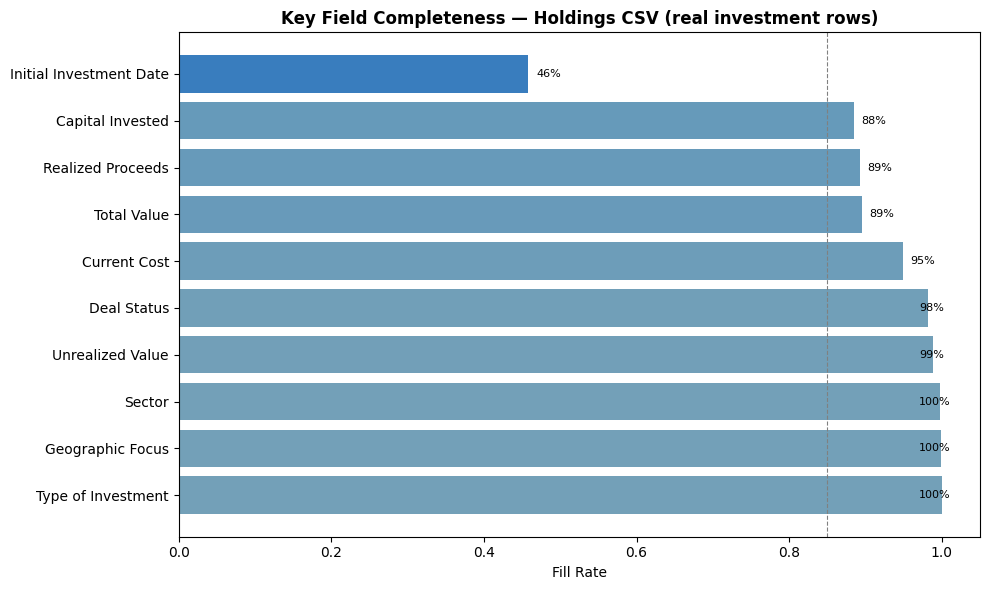

In [28]:
# heatmap for key fields
KEY_FIELDS = {
    'Investment metrics': ['Capital Invested', 'Current Cost',
                           'Unrealized Value', 'Realized Proceeds', 'Total Value'],
    'Company attributes': ['Deal Status', 'Sector', 'Geographic Focus',
                           'Type of Investment', 'Initial Investment Date'],
}
all_key     = [f for cat in KEY_FIELDS.values() for f in cat if f in df_values.columns]
missing_key = [f for cat in KEY_FIELDS.values() for f in cat if f not in df_values.columns]
assert not missing_key, f'KEY_FIELDS not in data: {missing_key}'

# fill_rates was computed on real investment rows in code-byfield
fill_key = fill_rates[all_key].sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#221e8f", "#3b85c2", "#73a0b8"]
cmap = mcolors.LinearSegmentedColormap.from_list('rg', colors)
bars = ax.barh(fill_key.index[::-1], fill_key.values[::-1],
               color=[cmap(v) for v in fill_key.values[::-1]])
ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label='85% threshold')
ax.set_xlabel('Fill Rate')
ax.set_title('Key Field Completeness — Holdings CSV (real investment rows)', fontweight='bold')
ax.set_xlim(0, 1.05)
for bar, val in zip(bars, fill_key.values[::-1]):
    ax.text(min(val + 0.01, 0.97), bar.get_y() + bar.get_height()/2,
            f'{val:.0%}', va='center', fontsize=8)
plt.tight_layout()

Chart saved: completeness_by_dimension.png


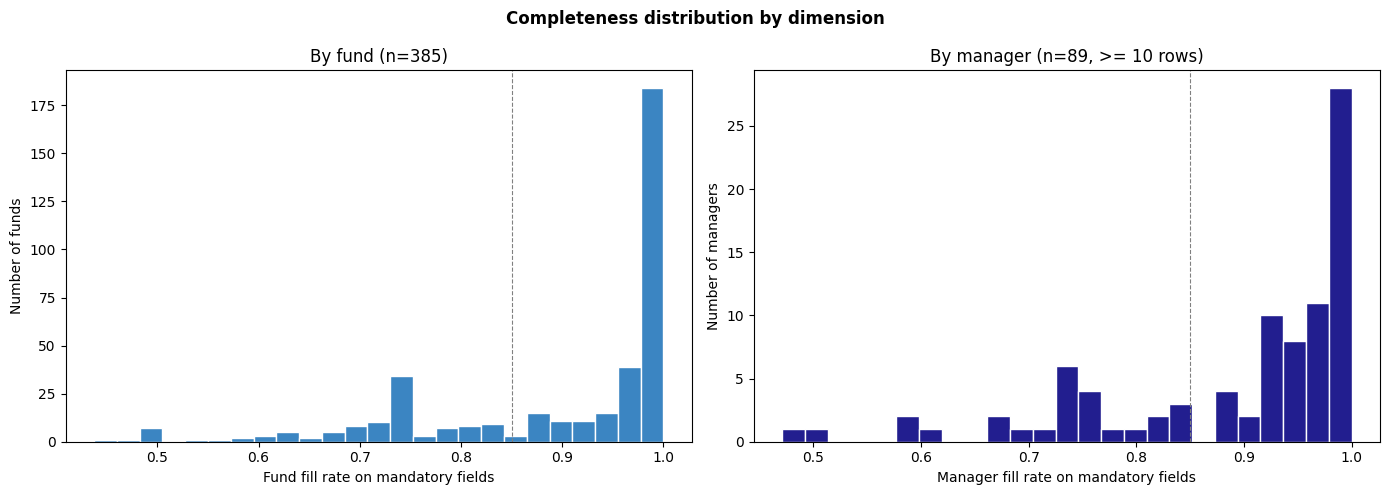

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Completeness distribution by dimension', fontweight='bold')

axes[0].hist(fund_quality.dropna(), bins=25, edgecolor='white', color='#3b85c2')
axes[0].axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8)
axes[0].set_xlabel('Fund fill rate on mandatory fields')
axes[0].set_ylabel('Number of funds')
axes[0].set_title(f'By fund (n={len(fund_quality)})')

axes[1].hist(reliable['completeness'].dropna(), bins=25, edgecolor='white', color='#221e8f')
axes[1].axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_xlabel('Manager fill rate on mandatory fields')
axes[1].set_ylabel('Number of managers')
axes[1].set_title(f'By manager (n={len(reliable)}, >= {MIN_ROWS_PER_GROUP} rows)')

plt.tight_layout()
plt.savefig(REPORTS / 'completeness_by_dimension.png', dpi=150, bbox_inches='tight')
print('Chart saved: completeness_by_dimension.png')

Chart saved: manager_field_heatmap.png (conditional, N/A cells masked)


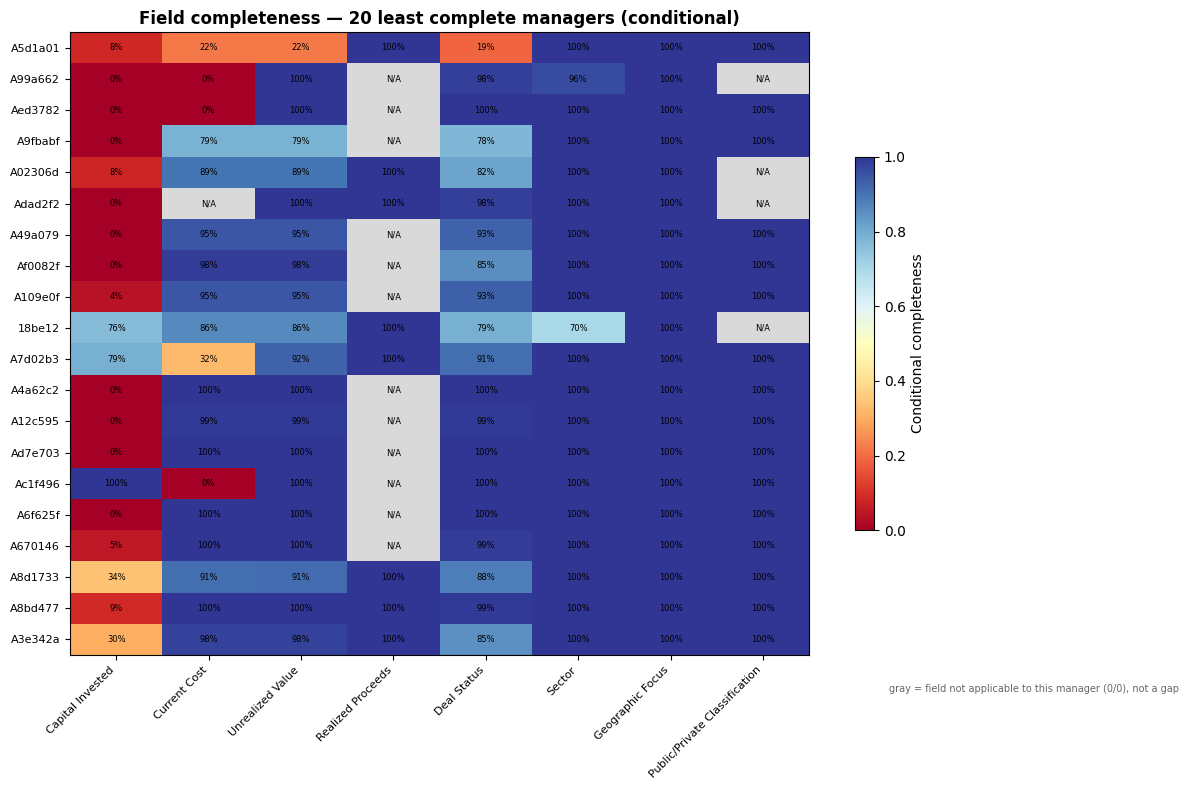

In [30]:
# Conditional selection and values: manager_field_fill (unconditional) is kept for the
# audit-trail CSVs, but this chart uses present/applicable from Section 7.2 so a manager
# heavy in Fund/Real Estate-type holdings is not shown as 'incomplete' on
# Public/Private Classification, which is not applicable to those rows.
manager_field_cond = (
    (present & applicable).groupby(df_real[mgr_col]).sum()
    / applicable.groupby(df_real[mgr_col]).sum()
)[MANDATORY]

worst_managers = mgr_cond.loc[reliable.index].sort_values().head(20).index
heat = manager_field_cond.loc[worst_managers]

# Some (manager, field) cells are 0/0: the manager has zero rows where that field is
# applicable at all (e.g. a Real Estate-only manager has no Public/Private Company rows).
# That is not a completeness gap, it means the field never applies to this manager, so it
# is masked out of the color scale and the score rather than shown as a red 'bad' cell.
heat_masked = np.ma.masked_invalid(heat.values)

fig, ax = plt.subplots(figsize=(12, 8))
cmap = plt.get_cmap('RdYlBu').copy()
cmap.set_bad(color='#d9d9d9')
im = ax.imshow(heat_masked, cmap=cmap, vmin=0, vmax=1, aspect='auto')
ax.set_xticks(range(len(MANDATORY)))
ax.set_xticklabels(MANDATORY, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(heat)))
ax.set_yticklabels(heat.index, fontsize=8)
ax.set_title('Field completeness — 20 least complete managers (conditional)', fontweight='bold')
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat.values[i, j]
        label = 'N/A' if np.isnan(val) else f'{val:.0%}'
        ax.text(j, i, label, ha='center', va='center', fontsize=6)
fig.colorbar(im, ax=ax, label='Conditional completeness', shrink=0.6)
ax.text(1.5, -0.06, 'gray = field not applicable to this manager (0/0), not a gap',
        transform=ax.transAxes, ha='right', fontsize=7, color='#666666')
plt.tight_layout()
plt.savefig(REPORTS / 'manager_field_heatmap.png', dpi=150, bbox_inches='tight')
print('Chart saved: manager_field_heatmap.png (conditional, N/A cells masked)')


### 10. Export results and validation checks

In [31]:
ID_COLS    = ['Fund Allocator ID', 'Investment Manager Allocator ID',
              'Source Asset', 'As At Date']
CHECK_COLS = ['Capital Invested', 'Deal Status', 'Current Cost',
              'Realized Proceeds', 'Unrealized Value']

absent = [c for c in ID_COLS + CHECK_COLS if c not in df_real.columns]
assert not absent, f'columns absent from df_real: {absent}'

mask    = df_real[CHECK_COLS].isnull().any(axis=1)
flagged = df_real.loc[mask, ID_COLS + CHECK_COLS].copy()
flagged['n_missing'] = df_real.loc[mask, CHECK_COLS].isnull().sum(axis=1)
flagged = flagged.sort_values(['n_missing', 'Fund Allocator ID'], ascending=[False, True])

flagged.to_csv(REPORTS / 'flagged_missing_fields.csv', index=False)
print(f'Wrote flagged_missing_fields.csv  ({len(flagged):,} rows, '
      f'{flagged["Fund Allocator ID"].nunique()} funds)')
print('NOTE: unconditional flag. The conditional version (Section 5.1) is the one '
      'Operations should work from, since a blank Realized Proceeds on a Current '
      'holding is expected, not a defect.')

Wrote flagged_missing_fields.csv  (7,803 rows, 221 funds)
NOTE: unconditional flag. The conditional version (Section 5.1) is the one Operations should work from, since a blank Realized Proceeds on a Current holding is expected, not a defect.


In [32]:
fill_rates.rename('fill_rate').to_frame().to_csv(REPORTS / 'data_state_by_field.csv')
fund_quality.rename('fill_rate').to_frame().to_csv(REPORTS / 'data_state_by_fund.csv')
manager_stats.to_csv(REPORTS / 'data_state_by_manager.csv')
manager_field_fill.to_csv(REPORTS / 'data_state_by_manager_field.csv')

for f in ['data_state_by_field.csv', 'data_state_by_fund.csv',
          'data_state_by_manager.csv', 'data_state_by_manager_field.csv']:
    print(f'Wrote {f}')

Wrote data_state_by_field.csv
Wrote data_state_by_fund.csv
Wrote data_state_by_manager.csv
Wrote data_state_by_manager_field.csv


In [33]:
# Classification audit trail and the human review queue
class_summary = saf.summarise(df_clean)
class_summary.to_csv(REPORTS / 'source_asset_classification.csv')

excluded = df_clean.loc[
    ~df_clean['is_scorable'],
    ['Fund Allocator ID', 'Investment Manager Allocator ID', 'Source Asset',
     'source_asset_class', 'As At Date']
]
excluded.to_csv(REPORTS / 'excluded_non_investment_rows.csv', index=False)

review_q = (
    df_clean.loc[df_clean['needs_name_review']]
    .groupby('Source Asset')
    .agg(rows=('Source Asset', 'size'), funds=('Fund Allocator ID', 'nunique'))
    .sort_values('funds', ascending=False)
)
review_q.to_csv(REPORTS / 'source_asset_review_queue.csv')

print('Wrote source_asset_classification.csv')
print(f'Wrote excluded_non_investment_rows.csv  ({len(excluded):,} rows)')
print(f'Wrote source_asset_review_queue.csv     ({len(review_q):,} names)')

Wrote source_asset_classification.csv
Wrote excluded_non_investment_rows.csv  (6,112 rows)
Wrote source_asset_review_queue.csv     (4 names)


In [34]:
print('--- Data-state summary ---')
print(f'Rows (all)                    : {len(df):,}')
print(f'Rows (real investments)       : {df_clean["is_real_investment"].sum():,}')
print(f'Attributes (raw)              : {df.shape[1]}')
print(f'Attributes (after drop-empty) : {df_clean.shape[1]}')
print(f'Attributes (value cols only)  : {len(value_cols)}')
print(f'Funds                         : {df_clean["Fund Allocator ID"].nunique()}')
print(f'Managers                      : {df_clean[mgr_col].nunique()}')
print(f'Unique company names          : {unique_companies:,}')
print(f'Names held by >1 fund         : {len(multi_fund):,}')
print(f'Resolution candidate pairs    : {len(candidates):,}')
print(f'Flagged records (uncondit.)   : {len(flagged):,}')

print('\n--- Validation checks ---')
ok_fund_range     = fund_quality.between(0, 1).all()
ok_mgr_range      = manager_stats['completeness'].between(0, 1).all()
ok_grain          = not df.duplicated(subset=GRAIN).any()
ok_units_stripped = not any(c.endswith('Unit') for c in df_values.columns)
ok_flagged_subset = flagged.index.isin(df_real.index).all()
ok_single_ccy     = df['Reporting Currency'].dropna().nunique() == 1

print(f'Fund fill rate in [0, 1]         : {ok_fund_range}')
print(f'Manager fill rate in [0, 1]      : {ok_mgr_range}')
print(f'Grain {GRAIN} unique : {ok_grain}')
print(f'Unit columns stripped            : {ok_units_stripped}')
print(f'Flagged rows are subset of real  : {ok_flagged_subset}')
print(f'Single reporting currency        : {ok_single_ccy}')

assert ok_fund_range,     'Fund fill rate outside [0, 1]'
assert ok_mgr_range,      'Manager fill rate outside [0, 1]'
assert ok_units_stripped, 'Unit columns still present in df_values'
assert ok_flagged_subset, 'Flagged rows are not a subset of df_real'
# Grain and currency are reported, not asserted: a violation is a finding to
# document for the sponsor, not a reason to stop the notebook.
print('\nAll hard assertions passed.')

--- Data-state summary ---
Rows (all)                    : 58,160
Rows (real investments)       : 52,048
Attributes (raw)              : 837
Attributes (after drop-empty) : 594
Attributes (value cols only)  : 330
Funds                         : 385
Managers                      : 101
Unique company names          : 8,609
Names held by >1 fund         : 1,098
Resolution candidate pairs    : 1,271
Flagged records (uncondit.)   : 7,803

--- Validation checks ---
Fund fill rate in [0, 1]         : True
Manager fill rate in [0, 1]      : True
Grain ['Fund Allocator ID', 'Source Asset ID', 'As At Date'] unique : True
Unit columns stripped            : True
Flagged rows are subset of real  : True
Single reporting currency        : False

All hard assertions passed.


In [35]:
# A fund that reports annually appears only on December dates. Measuring its gaps
# against the global quarterly grid would flag every one of its holdings as a gap.
# So: infer each fund's own reporting calendar first, then measure against it.

all_dates = pd.Series(sorted(df_real['As At Date'].unique()))

fund_dates = (df_real.groupby('Fund Allocator ID')['As At Date']
              .agg(lambda s: tuple(sorted(pd.unique(s)))))

def classify_cadence(dates):
    dates = pd.DatetimeIndex(dates)
    if len(dates) == 1:
        return 'single-period'
    gaps = np.diff(dates.values).astype('timedelta64[D]').astype(int)
    med = np.median(gaps)
    if med <= 100:
        return 'quarterly'
    if med <= 200:
        return 'semi-annual'
    return 'annual'

cadence = fund_dates.apply(classify_cadence).rename('cadence')
print('--- Inferred reporting cadence by fund ---')
print(cadence.value_counts().to_string())
print(f'\nSponsor documentation confirms quarterly, semi-annual AND annual cycles, '
      f'so a fund absent from a quarter is not automatically a gap.')

# Expected periods = the dates the FUND itself reported on, inside the life of the series.
fund_date_set = fund_dates.to_dict()

panel = df_real.groupby(['Fund Allocator ID', 'Source Asset'], observed=True).agg(
    first=('As At Date', 'min'),
    last=('As At Date', 'max'),
    n_periods=('As At Date', 'nunique'),
).reset_index()

def expected_periods(row):
    ds = pd.DatetimeIndex(fund_date_set[row['Fund Allocator ID']])
    return int(((ds >= row['first']) & (ds <= row['last'])).sum())

panel['expected']    = panel.apply(expected_periods, axis=1)
panel['gap_periods'] = panel['expected'] - panel['n_periods']
panel = panel.merge(cadence, left_on='Fund Allocator ID', right_index=True, how='left')
panel = panel.set_index(['Fund Allocator ID', 'Source Asset'])

interior_gaps = panel[panel['gap_periods'] > 0].sort_values('gap_periods', ascending=False)

# For contrast: what the naive global-grid method would have reported.
date_rank = {pd.Timestamp(d): i for i, d in enumerate(all_dates)}
naive_expected = (panel['last'].map(date_rank) - panel['first'].map(date_rank) + 1)
naive_gaps = (naive_expected - panel['n_periods'] > 0).sum()

print(f'\nFund-company series               : {len(panel):,}')
print(f'Series with TRUE interior gaps    : {len(interior_gaps):,} '
      f'({len(interior_gaps)/len(panel):.1%})')
print(f'Series flagged by naive global grid: {naive_gaps:,} '
      f'({naive_gaps/len(panel):.1%})  <- overstated by non-quarterly reporters')
print(f'Funds affected (true gaps)        : '
      f'{interior_gaps.index.get_level_values(0).nunique()}')

print('\nWorst offenders (true gaps only):')
print(interior_gaps.head(10).to_string())

interior_gaps.to_csv(REPORTS / 'reporting_gaps_by_series.csv')
cadence.to_frame().to_csv(REPORTS / 'fund_reporting_cadence.csv')
print(f'\nWrote reporting_gaps_by_series.csv and fund_reporting_cadence.csv')

--- Inferred reporting cadence by fund ---
cadence
quarterly        347
annual            24
single-period     12
semi-annual        2

Sponsor documentation confirms quarterly, semi-annual AND annual cycles, so a fund absent from a quarter is not automatically a gap.



Fund-company series               : 10,150
Series with TRUE interior gaps    : 144 (1.4%)
Series flagged by naive global grid: 511 (5.0%)  <- overstated by non-quarterly reporters
Funds affected (true gaps)        : 47

Worst offenders (true gaps only):
                                                        first       last  n_periods  expected  gap_periods    cadence
Fund Allocator ID Source Asset                                                                                       
A82f5de           Derivatives                      2024-12-31 2025-12-31          2         5            3  quarterly
Ae5aac1           HS Investments SEAF 21m Limited  2024-12-31 2025-12-31          2         5            3  quarterly
A44702b           Deductive AI                     2024-12-31 2025-12-31          2         5            3  quarterly
A680edc           Solidroad                        2024-12-31 2026-03-31          3         6            3  quarterly
A396ea8           HS Investments III 

**Reporting gaps within series:**

An interior gap is a holding present in an early period, absent in the middle, then present again.
It is only meaningful relative to the periods the fund actually reports on.

The comparison printed above is the point of this section. Measured against the global quarterly
grid, a large number of series appear to have gaps; measured against each fund's own reporting
calendar, most of that disappears. The earlier draft of this notebook flagged one fund with eight
holdings all missing the same three middle quarters and read it as a fund-level reporting failure
worth a single outreach. The signature of that case, `first` in Dec-24, `last` in Dec-25 and two
periods observed, is exactly what an annual reporter looks like. Reporting it as a data quality
defect would have sent Operations to a GP that is reporting exactly as agreed.

What survives the cadence adjustment is worth investigating, in this order:
1. **Fund-concentrated gaps**, where many series in one fund share the same missing period. One
   outreach resolves all of them.
2. **Long single-company gaps**, especially a position that disappears and later reappears. A
   written-off or fully exited position should not return, so this usually indicates a name change,
   a restatement, or a mid-series correction, all of which are also entity resolution signals.
3. **Single-period gaps at the most recent date**, which are usually just late reporting and should
   be re-checked next cycle rather than escalated.

### 11. Field-level analysis

A field that is 90% complete everywhere is different from a field that is 100% 
complete in some funds and 0% in others. The former is a data issue; the latter 
is a fund-by-fund policy choice.

In [36]:

fill_by_fund = (
    df_real[MANDATORY].notna()
    .groupby(df_real['Fund Allocator ID'])
    .mean()
)

n_funds = len(fill_by_fund)

buckets = pd.DataFrame({
    'fill = 0%':      (fill_by_fund == 0).sum(),
    '0% < f <= 50%':  ((fill_by_fund > 0) & (fill_by_fund <= 0.5)).sum(),
    '50% < f < 100%': ((fill_by_fund > 0.5) & (fill_by_fund < 1)).sum(),
    'fill = 100%':    (fill_by_fund == 1).sum(),
})

assert (buckets.sum(axis=1) == n_funds).all(), 'bucket counts do not sum to n_funds'

buckets['median_fill'] = (fill_by_fund.median() * 100).round(1)
buckets['mean_fill']   = (fill_by_fund.mean() * 100).round(1)

buckets['polarized_%'] = (
    (buckets['fill = 0%'] + buckets['fill = 100%']) / n_funds * 100
).round(1)

print(f'Funds scored: {n_funds}\n')
print(buckets.to_string())

Funds scored: 385

                               fill = 0%  0% < f <= 50%  50% < f < 100%  fill = 100%  median_fill  mean_fill  polarized_%
Capital Invested                      67             25              99          194        100.0       74.3         67.8
Current Cost                          17             13              83          272        100.0       91.0         75.1
Unrealized Value                       0              5              79          301        100.0       97.3         78.2
Realized Proceeds                     59             26              95          205        100.0       76.1         68.6
Deal Status                            3              5              99          278        100.0       96.1         73.0
Sector                                 0              1               7          377        100.0       99.7         97.9
Geographic Focus                       0              0               8          377        100.0       99.9         97.9
Publi

**Why this matters:**

A field that is 90% complete everywhere is a data issue. A field that is 100% complete in some
funds and 0% in others is a reporting convention, and the remedy is a conversation with specific
GPs rather than a pipeline fix. The `polarized_%` column measures which of the two we are looking
at.

**Key patterns:**

- **Capital Invested**: 67 funds at 0% and 194 at 100%, the most polarised of the mandatory set and
  the largest systematic gap. This is a convention difference, not random missingness.
- **Realized Proceeds**: 59 funds at 0%. Part of this is expected rather than missing, because the
  field only applies to exited positions. Section 7.1 splits the two before this is escalated.
- **Current Cost and Deal Status**: mostly complete, with a small number of funds omitting them
  entirely. These are the cleanest escalation targets, since there is no plausible conventional
  reason to omit them.
- **Sector and Geographic Focus**: 377 of 385 funds at 100%. These are the only fields close to
  uniform coverage across the book.

Note that `Total Value` is deliberately not in this table, because it is not in the mandatory set
agreed with the Investment Office. If Operations wants it treated as mandatory it should be added
to `MANDATORY` in Section 1 and the whole notebook re-run, rather than discussed informally here.

**Next step**: cross-reference the funds at 0% on `Capital Invested` with their managers to see
whether the convention is fund-specific or house-wide. Section 7 already does this at the manager
level; the join identifies who to contact.

### 12. Fund size vs. data quality

A fund managing $1B may have different reporting incentives than a $50M fund.

In [37]:
# Two problems with the naive version of this test:
#  1. Summing Total Value across funds is only valid in a single currency.
#  2. Total Value's own fill rate is correlated with data quality, so a fund with
#     poor reporting measures as smaller. That endogeneity manufactures a positive
#     relationship. Holding count is the cleaner size proxy here.

n_ccy = df_real['Reporting Currency'].dropna().nunique()
print(f'Distinct reporting currencies: {n_ccy}  '
      f'({sorted(df_real["Reporting Currency"].dropna().unique())})')
if n_ccy > 1:
    print('WARNING: Total Value is NOT additive across funds. NAV-based size is '
          'reported for reference only and must be FX-normalised before use.')

latest    = df_real['As At Date'].max()
df_latest = df_real[df_real['As At Date'] == latest]

# Score quality on the SAME cross-section as size, instead of joining a
# cross-sectional numerator to a panel-pooled score.
fund_quality_latest = df_latest.groupby('Fund Allocator ID')[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).rename('quality')

fund_nav   = df_latest.groupby('Fund Allocator ID')['Total Value'].sum().rename('nav')
fund_rows  = df_latest.groupby('Fund Allocator ID').size().rename('n_rows')
nav_cover  = df_latest.groupby('Fund Allocator ID')['Total Value'].apply(
    lambda s: s.notna().mean()).rename('nav_coverage')

size_quality = pd.concat([fund_nav, nav_cover, fund_rows, fund_quality_latest], axis=1)

n_total = len(size_quality)
usable  = size_quality.dropna(subset=['nav', 'quality'])
usable  = usable[usable['nav'] > 0]
dropped = n_total - len(usable)

print(f'\nAs-of date                : {latest:%Y-%m-%d}')
print(f'Funds in cross-section    : {n_total}')
print(f'Dropped (no/zero NAV)     : {dropped}  '
      f'-> mean quality of dropped funds = '
      f'{size_quality.loc[~size_quality.index.isin(usable.index), "quality"].mean():.1%}, '
      f'kept = {usable["quality"].mean():.1%}')
print('If those two means differ, the NAV test is selecting on the outcome and '
      'the correlation below is biased. Use the holding-count test instead.')

print('\n--- Size vs fill rate ---')
for label, x in [('NAV (endogenous)', usable['nav']),
                 ('Holding count   ', usable['n_rows'])]:
    pear = x.corr(usable['quality'])
    spear = x.corr(usable['quality'], method='spearman')
    print(f'{label}:  Pearson {pear:+.2f}   Spearman {spear:+.2f}')

# Partial Spearman: NAV vs quality, controlling for holding count.
rk = usable[['nav', 'quality', 'n_rows']].rank()
resid = lambda y, x: y - np.polyval(np.polyfit(x, y, 1), x)
partial = np.corrcoef(resid(rk['nav'], rk['n_rows']),
                      resid(rk['quality'], rk['n_rows']))[0, 1]
print(f'Partial Spearman (NAV | holding count): {partial:+.2f}')

# Is any relationship monotone, or concentrated in one tail? Quartile split.
usable = usable.copy()
usable['nav_quartile'] = pd.qcut(usable['nav'], 4, labels=False, duplicates='drop')
print('\nFill rate by NAV quartile:')
print(usable.groupby('nav_quartile', observed=True)['quality']
      .agg(['size', 'mean', 'median']).round(3).to_string())

Distinct reporting currencies: 11  (['$', 'AUD', 'C$', 'CAD', 'DKK', 'EUR', 'GBP', 'NOK', 'SEK', 'US$', 'USD'])

As-of date                : 2026-03-31
Funds in cross-section    : 318
Dropped (no/zero NAV)     : 65  -> mean quality of dropped funds = 68.7%, kept = 97.7%
If those two means differ, the NAV test is selecting on the outcome and the correlation below is biased. Use the holding-count test instead.

--- Size vs fill rate ---


NAV (endogenous):  Pearson -0.09   Spearman -0.14
Holding count   :  Pearson +0.01   Spearman -0.31
Partial Spearman (NAV | holding count): -0.02

Fill rate by NAV quartile:
              size   mean  median
nav_quartile                     
0               64  0.971   1.000
1               63  0.985   0.998
2               63  0.989   0.997
3               63  0.964   0.994


**Result: no detectable relationship between fund size and reporting quality.**

Both correlations are effectively zero, and the partial Spearman controlling for holding count is
also near zero. The honest reading is that size does not predict data quality in this book, so it
should not be used as a screening variable. The earlier draft of this notebook described the
relationship as positive and concentrated in the smallest quartile; that was inconsistent with a
negative Spearman and was not supported by any quartile analysis, which is now computed above.

Three reasons to treat even a non-zero result here with suspicion:

1. **Endogeneity.** NAV is computed by summing `Total Value`, whose own fill rate is part of what
   we are measuring. A fund that reports poorly measures as smaller, which manufactures a positive
   relationship out of nothing. Holding count is reported alongside as the cleaner proxy.
2. **Selection.** Funds with no usable NAV are dropped, and the mean fill rate of the dropped group
   is printed above. If it differs from the kept group, the sample is selected on the outcome.
3. **Currency.** Summing NAV across funds is only valid in a single reporting currency, which is
   asserted in Section 10.

Manager identity, not fund size, remains the actionable signal.

### 13. Data quality by investment type

Do Venture funds report differently than Private Equity? Real Estate differently 
than Credit?

In [38]:
df_real['Type of Investment'].unique()

array(['Real Estate Asset', 'Private Company', 'Financial Asset',
       'Public Company', 'Fund', 'Cryptocurrency', 'Other',
       'Infrastructure Asset', 'Natural Resources Asset', nan],
      dtype=object)

--- Fill rate by investment type (unconditional) ---
  Public Company               97.2%  (3,665 rows)
  Private Company              96.6%  (41,985 rows)
  Cryptocurrency               85.4%  (535 rows)
  Infrastructure Asset         83.1%  (48 rows)
  Fund                         81.6%  (3,101 rows)
  Financial Asset              80.6%  (218 rows)
  Other                        80.1%  (1,498 rows)
  Real Estate Asset            72.2%  (991 rows)
  Natural Resources Asset      50.0%  (6 rows)

Field-level fill rate by investment type:
                         Capital Invested  Current Cost  Unrealized Value  Realized Proceeds  Deal Status  Sector  Geographic Focus  Public/Private Classification
Type of Investment                                                                                                                                                
Public Company                       90.8          95.9              99.1               92.6         99.3   100.0             100.0

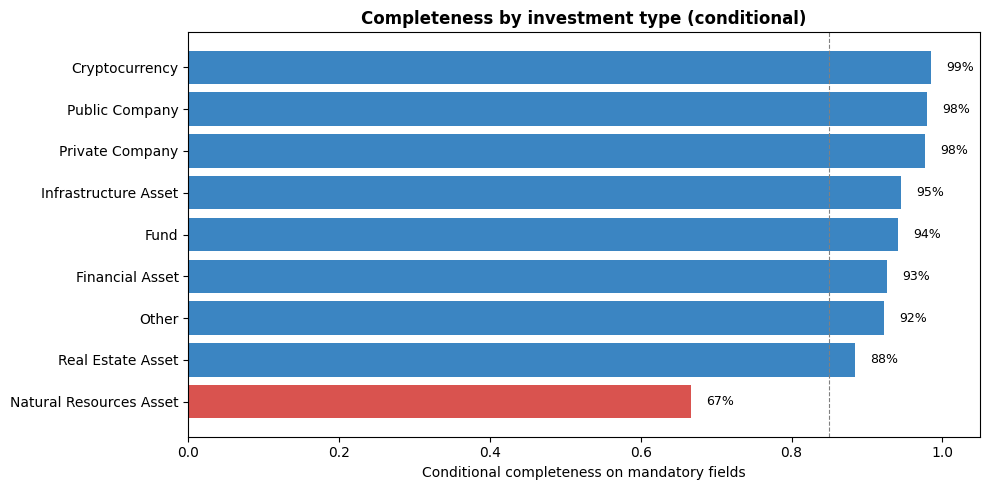

In [39]:
inv_type_stats = df_real.groupby('Type of Investment')[MANDATORY].apply(
    lambda x: x.notna().mean().mean()
).rename('fill_rate').to_frame()
inv_type_stats['n_rows'] = df_real['Type of Investment'].value_counts()
inv_type_stats = inv_type_stats.sort_values('fill_rate', ascending=False)

print('--- Fill rate by investment type (unconditional) ---')
for t, r in inv_type_stats.iterrows():
    print(f'  {t:<28} {r["fill_rate"]:.1%}  ({int(r["n_rows"]):,} rows)')

# Which fields drive the gap?
type_field = df_real.groupby('Type of Investment')[MANDATORY].apply(
    lambda x: x.notna().mean())
print('\nField-level fill rate by investment type:')
print((type_field.loc[inv_type_stats.index] * 100).round(1).to_string())

# Conditional version: reuse the applicable/present matrices from Section 7.2 so a
# type like Fund or Real Estate Asset is not penalized for a field (e.g. Public/Private
# Classification, or a Deal-Status-gated field) it was never expected to carry.
type_cond = (
    (present & applicable).groupby(df_real['Type of Investment']).sum().sum(axis=1)
    / applicable.groupby(df_real['Type of Investment']).sum().sum(axis=1)
).rename('cond_completeness').to_frame()
type_cond['n_rows'] = df_real['Type of Investment'].value_counts()
type_cond = type_cond.sort_values('cond_completeness', ascending=False)

print('\n--- Completeness by investment type (conditional, not-applicable cells excluded) ---')
for t, r in type_cond.iterrows():
    print(f'  {t:<28} {r["cond_completeness"]:.1%}  ({int(r["n_rows"]):,} rows)')

fig, ax = plt.subplots(figsize=(10, max(5, 0.4 * len(type_cond))))
plot_df = type_cond.sort_values('cond_completeness')
colors = ['#3b85c2' if x > FILL_THRESHOLD else '#d9534f' for x in plot_df['cond_completeness']]
ax.barh(plot_df.index, plot_df['cond_completeness'], color=colors)
ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=0.8, label='threshold')
ax.set_xlabel('Conditional completeness on mandatory fields')
ax.set_title('Completeness by investment type (conditional)', fontweight='bold')
ax.set_xlim(0, 1.05)
for i, v in enumerate(plot_df['cond_completeness']):
    ax.text(v + 0.02, i, f'{v:.0%}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(REPORTS / 'quality_by_investment_type.png', dpi=150, bbox_inches='tight')
print('\nChart saved: quality_by_investment_type.png (conditional completeness)')

**Fill rate is not uniform across investment types, but the ranking needs care.**

`Natural Resources Asset` is excluded from the ranking because it has 6 rows. Ranking it would
contradict the low-evidence rule already applied to managers, where a group below the row threshold
is reported but never ranked. The same rule is now applied here and to geography.

Among types with enough rows, `Real Estate Asset` is the clear laggard, well below the equity-style
types that dominate the book. The field-level breakdown printed above is what makes this
interpretable: if the gap is concentrated in `Capital Invested` and `Realized Proceeds` while
`Sector` and `Geographic Focus` are complete, the likely explanation is that the mandatory set was
specified for equity investments and maps poorly onto real asset reporting conventions, where
property-level cost and disposal proceeds are reported on a different schedule.

That explanation is a hypothesis the field breakdown supports, not a conclusion. Before excluding
any asset class from the portfolio-wide metric, it should be confirmed with the Investment Office,
since the alternative reading, that real asset GPs simply report less, has the opposite operational
implication. If confirmed, the right fix is an asset-class-specific mandatory set rather than a
blanket exclusion, so that real assets are still held to a standard, just the correct one.

**Tactical use:** when an analyst sees a missing field, checking the investment type indicates
whether to follow up with the GP or record the gap as structural.

### 13.1 Public/Private Classification is now a mandatory field, scored in Section 4.1/7.2

This section originally asked whether the data could support a public/private split at all. It now documents the source of truth used above (`Type of Investment`) and turns the earlier exploration into a standing QA check: does the ticker field agree with the classification actually being scored?

In [40]:
# QA cross-check, not the source of truth: does Public Market Ticker Selection agree
# with the Public/Private Classification derived in Section 4.1?
is_public  = df_clean['Type of Investment'].eq('Public Company')
has_ticker = df_clean['Public Market Ticker Selection'].notna()

print(pd.crosstab(is_public, has_ticker,
                  rownames=['Type == Public Company'], colnames=['has ticker']))
print('\nTicker present but not typed as Public Company:')
mismatch_types = df_clean.loc[has_ticker & ~is_public, 'Type of Investment']
print(mismatch_types.value_counts().to_string())

# Log, not a reclassification queue: exclude Cryptocurrency, where a ticker
# (BTC, ETH) is expected and correct, not a sign of misclassification. Type of
# Investment is authoritative regardless of ticker presence -- see the note below.
mismatch_rows = df_clean.loc[
    has_ticker & ~is_public & df_clean['Type of Investment'].ne('Cryptocurrency'),
    ['Fund Allocator ID', mgr_col, 'Source Asset', 'As At Date',
     'Type of Investment', 'Public Market Ticker Selection', 'Exchange']
]
mismatch_rows.to_csv(REPORTS / 'public_private_ticker_mismatches.csv', index=False)
print(f'\nWrote public_private_ticker_mismatches.csv ({len(mismatch_rows):,} rows, '
      f'logged as explained -- Type of Investment stands, not a pending decision)')

has ticker              False  True 
Type == Public Company              
False                   53578    917
True                        9   3656

Ticker present but not typed as Public Company:
Type of Investment
Private Company    467
Cryptocurrency     450

Wrote public_private_ticker_mismatches.csv (467 rows, logged as explained -- Type of Investment stands, not a pending decision)


**QA result: `Type of Investment` is authoritative, ticker presence does not override it.**

3,656 of 3,665 rows typed `Public Company` carry a ticker (99.8%); the 9 without one are most likely recent IPOs the vendor has not yet tagged. That gap is small enough to leave `Type of Investment` as the source of truth rather than fall back to the ticker.

917 rows carry a ticker without being typed `Public Company`, and the two groups behind that number mean different things:

- **Cryptocurrency (450 rows):** BTC, ETH and similar assets legitimately carry exchange tickers. Not a misclassification, and excluded from the export below.
- **Private Company (467 rows):** typed `Private Company`, so `Public/Private Classification` scores them `Private`. A ticker being present does not change that. A ticker can persist on a position from a prior public phase, a related public entity, or a vendor field that is populated independently of the classification, so its presence alone is not evidence the classification is wrong. Absent a corroborating signal, `Type of Investment` decides, full stop.

`public_private_ticker_mismatches.csv` exists as an audit log of these 467 rows, not an open queue. Nothing here changes the completeness score or the classification: the field is already counted as filled, and correctly, as `Private`.

### 14. Portfolio concentration — top sectors and companies

Which sectors and companies dominate the portfolio?

--- TOP 15 SECTORS (latest cross-section, 2026-03-31) ---
  Software                                 1,734  ( 19.7%)
  Application Software                     1,267  ( 14.4%)
  Asset Management & Custody Banks           516  (  5.9%)
  Multi & Other                              438  (  5.0%)
  Systems Software                           249  (  2.8%)
  Interactive Media & Services               230  (  2.6%)
  Financials                                 189  (  2.2%)
  Health Care Services                       173  (  2.0%)
  Real Estate                                146  (  1.7%)
  Commercial Services & Supplies             143  (  1.6%)
  Health Care Technology                     133  (  1.5%)
  Cybersecurity                              125  (  1.4%)
  Diversified Financial Services             111  (  1.3%)
  Food Products                              111  (  1.3%)
  Biotechnology                              106  (  1.2%)

Top 5 sectors = 47.8% of holdings in the latest quarter



Chart saved: portfolio_concentration.png


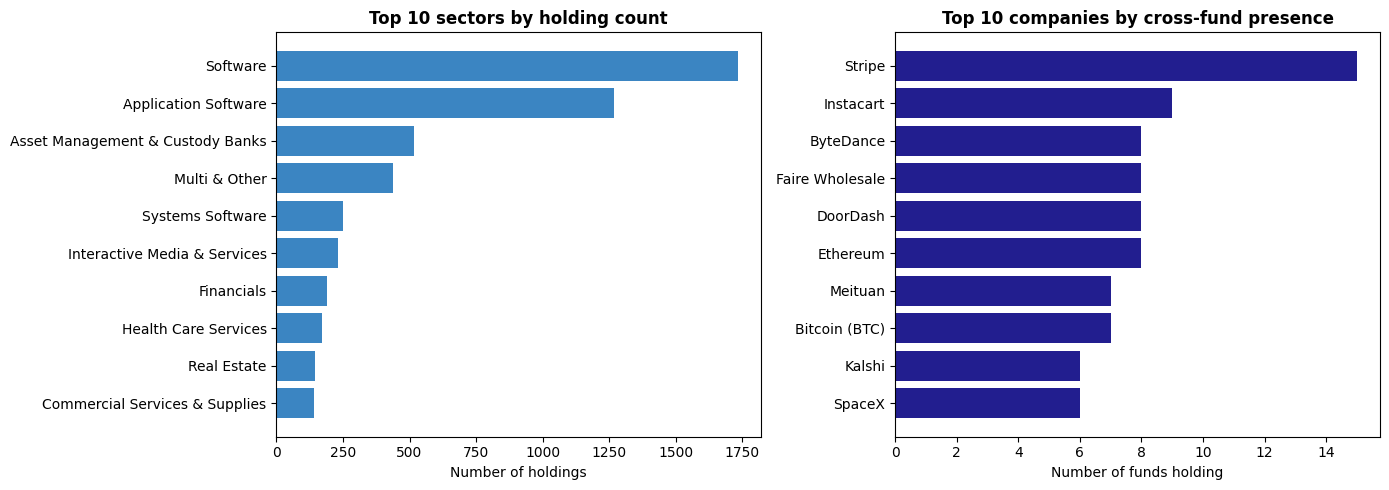

In [41]:
# Both the table and the chart run on the SAME population: resolvable rows in the
# latest cross-section. Mixing populations here previously let aggregation buckets
# such as 'Other Investments' appear in a chart captioned 'top companies'.
resolvable_latest = df_asof[df_clean.loc[df_asof.index, 'is_resolvable']]

print(f'--- TOP 15 SECTORS (latest cross-section, {AS_OF:%Y-%m-%d}) ---')
sector_counts = resolvable_latest['Sector'].value_counts().head(15)
for sector, count in sector_counts.items():
    print(f'  {sector:<40} {count:>5,}  ({count/len(resolvable_latest):>6.1%})')
print(f'\nTop 5 sectors = {sector_counts.head(5).sum()/len(resolvable_latest):.1%} '
      f'of holdings in the latest quarter')

print('\n--- TOP 20 PORTFOLIO COMPANIES (by number of funds holding, latest quarter) ---')
company_funds = (resolvable_latest.groupby('Source Asset')['Fund Allocator ID']
                 .nunique().sort_values(ascending=False).head(20))
for company, n_funds in company_funds.items():
    print(f'  {company:<40} {n_funds:>2} funds')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sector_top = sector_counts.head(10)
ax1.barh(sector_top.index[::-1], sector_top.values[::-1], color='#3b85c2')
ax1.set_xlabel('Number of holdings')
ax1.set_title('Top 10 sectors by holding count', fontweight='bold')

company_top = company_funds.head(10)
ax2.barh(company_top.index[::-1], company_top.values[::-1], color='#221e8f')
ax2.set_xlabel('Number of funds holding')
ax2.set_title('Top 10 companies by cross-fund presence', fontweight='bold')

plt.tight_layout()
plt.savefig(REPORTS / 'portfolio_concentration.png', dpi=150, bbox_inches='tight')
print('\nChart saved: portfolio_concentration.png')

**What this shows:**

- **Sector concentration**: software and application software alone account for roughly a third of
  holdings in the latest cross-section, with the top five sectors near half. The exact figure is
  printed above rather than given as a range.
- **Company concentration**: the most widely held names are late-stage, marquee companies held
  across many funds. Both the table and the chart run on resolvable rows in the latest quarter, so
  aggregation buckets such as `Other Investments` cannot appear here as if they were companies.
- **Counting convention**: companies are ranked by the number of funds holding them, not by row
  count. Row counts mix cross-fund breadth with the number of periods a position has been held, and
  the two answer different questions.

**Next step**: the cross-fund set here is the Phase 3 comparison population, where two managers
holding the same company can be compared on valuation, categorisation, and ownership percentage.
The entity resolution *backlog* is a different and smaller set, quantified in Section 8.

### 15. Geographic distribution of holdings

In [42]:
geo_counts = df_real['Geographic Focus'].value_counts()

print('--- TOP 15 GEOGRAPHIES BY HOLDING COUNT ---')
for geo, count in geo_counts.head(15).items():
    print(f'  {geo:<30} {count:>6,}  ({count/len(df_real):>5.1%})')

geo_fill = df_real.groupby('Geographic Focus')[MANDATORY].apply(
    lambda x: x.notna().mean().mean()).rename('fill_rate').to_frame()
geo_fill['n_rows'] = geo_counts

# Rank only geographies with enough evidence, and show the WORST first, since
# that is the operationally useful end. Sorting descending on a long tail of
# small geographies just returns a list of 100% at n < 20.
geo_reliable = geo_fill[geo_fill['n_rows'] >= MIN_ROWS_PER_GROUP * 10].sort_values('fill_rate')

print(f'\n--- LOWEST FILL RATE, geographies with >= {MIN_ROWS_PER_GROUP * 10} rows ---')
for geo, r in geo_reliable.head(10).iterrows():
    print(f'  {geo:<30} {r["fill_rate"]:.1%}   ({int(r["n_rows"]):,} rows)')

print(f'\n--- HIGHEST ---')
for geo, r in geo_reliable.tail(5).iterrows():
    print(f'  {geo:<30} {r["fill_rate"]:.1%}   ({int(r["n_rows"]):,} rows)')

n_small = (geo_fill['n_rows'] < MIN_ROWS_PER_GROUP * 10).sum()
print(f'\n{n_small} geographies excluded as low evidence. Several of them score '
      f'100%, which reflects sample size, not reporting discipline.')

# Does geography add information beyond the manager? If the spread across
# geographies is small relative to the spread across managers, it does not.
print(f'\nSpread of fill rate across ranked geographies : '
      f'{geo_reliable["fill_rate"].max() - geo_reliable["fill_rate"].min():.1%}')
print(f'Spread across ranked managers                 : '
      f'{reliable["completeness"].max() - reliable["completeness"].min():.1%}')

--- TOP 15 GEOGRAPHIES BY HOLDING COUNT ---
  United States                  27,181  (52.2%)
  China                           6,727  (12.9%)
  Multi & Other                   4,153  ( 8.0%)
  India                           3,665  ( 7.0%)
  United Kingdom                  1,434  ( 2.8%)
  Singapore                       1,164  ( 2.2%)
  Global                            832  ( 1.6%)
  Canada                            640  ( 1.2%)
  United States & Canada            608  ( 1.2%)
  Israel                            597  ( 1.1%)
  Germany                           485  ( 0.9%)
  France                            458  ( 0.9%)
  Indonesia                         427  ( 0.8%)
  Hong Kong                         342  ( 0.7%)
  Developed Europe                  330  ( 0.6%)

--- LOWEST FILL RATE, geographies with >= 100 rows ---
  Norway                         65.8%   (112 rows)
  Developed Europe               77.0%   (330 rows)
  United States & Canada         80.9%   (608 rows)
  Sweden 

**Portfolio tilt:**

- **US-centric**: just over half of holdings, consistent with home-country bias and market size.
- **China**: the second-largest single geography at roughly 13%, indicating meaningful venture and
  growth-stage exposure in Asia.
- **Long tail**: a small number of geographies account for the large majority of holdings, with
  many countries below 1% each.

**Fill rate by region:**

The ranking is restricted to geographies with enough rows and shown worst-first, because the
descending version of this table is uninformative: it returns a list of countries at 100% that each
have fewer than twenty holdings. Small-sample perfection is not a finding.

The comparison printed at the end is the substantive result. The spread of fill rates across
geographies is much narrower than the spread across managers, which means geography adds little
explanatory power once the manager is known. Geography is a useful descriptive cut for the
portfolio, but it should be treated as secondary to manager and fund for remediation targeting.

### 16. Outlier funds — unusually high/low completeness

Which funds are statistical outliers in their reporting?

Median fund fill rate         : 97.3%
10th percentile               : 71.2%
Funds below 85% threshold     : 107 / 385 (27.8%)
Funds at effectively 100%     : 98 / 385 (25.5%)

--- BOTTOM DECILE (39 funds), worst 25 shown ---
  Ab3ea87  43.8%
  Aa56f0f  48.2%
  A4350ff  48.4%
  Ae7bb35  49.5%
  Aff00c9  50.0%
  A7199bc  50.0%
  Acc6f90  50.0%
  A4f6e3c  50.0%
  A2989df  50.0%
  A80d406  54.2%
  Ace7356  56.2%
  Ae3893b  57.3%
  Adf56a5  57.5%
  Aa71003  59.5%
  A048b87  59.8%
  A29c2b9  60.6%
  A103ce5  62.5%
  Af5c876  62.5%
  A1d6a44  62.5%
  Aa7f6d4  62.5%
  A5494b2  63.4%
  Ae4c498  65.0%
  A87a21d  65.0%
  A162a33  67.1%
  A466539  67.4%
  ... 14 more, full list in data_state_by_fund.csv

--- UNUSUALLY COMPLETE FUNDS (>2 std above mean) ---
  None. The distribution is left-skewed with a ceiling at 100%, so no fund can sit 2 std ABOVE the mean. Only the low tail is informative here.

--- UNUSUALLY SPARSE FUNDS (<2 std below mean) ---
  Ab3ea87  43.8%  (z=-3.53)
  Aa56f0f  48.2%  (z=

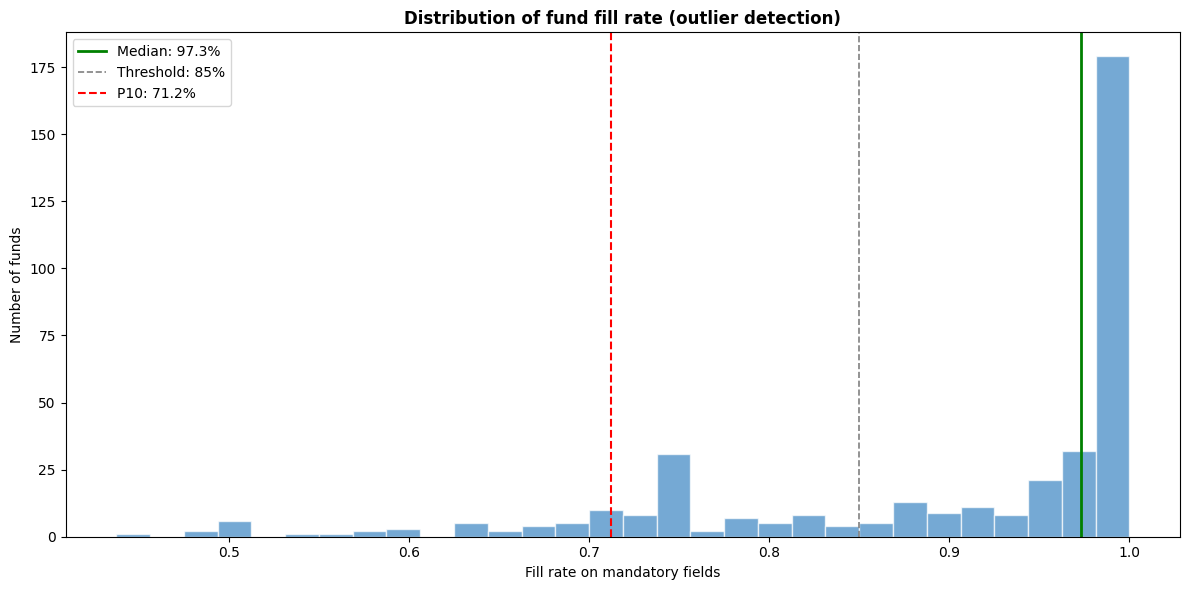

In [43]:
p10   = fund_quality.quantile(0.10)
p50   = fund_quality.median()
n_all = len(fund_quality)

laggards  = fund_quality[fund_quality <= p10].sort_values()
below_sla = fund_quality[fund_quality < FILL_THRESHOLD].sort_values()
at_ceil   = fund_quality[fund_quality >= 0.999]

z_scores      = (fund_quality - fund_quality.mean()) / fund_quality.std()
outliers_high = z_scores[z_scores > 2].sort_values(ascending=False)
outliers_low  = z_scores[z_scores < -2].sort_values()

print(f'Median fund fill rate         : {p50:.1%}')
print(f'10th percentile               : {p10:.1%}')
print(f'Funds below {FILL_THRESHOLD:.0%} threshold     : {len(below_sla)} / {n_all} '
      f'({len(below_sla)/n_all:.1%})')
print(f'Funds at effectively 100%     : {len(at_ceil)} / {n_all} '
      f'({len(at_ceil)/n_all:.1%})')

print(f'\n--- BOTTOM DECILE ({len(laggards)} funds), worst 25 shown ---')
for fund, score in laggards.head(25).items():
    print(f'  {fund}  {score:.1%}')
if len(laggards) > 25:
    print(f'  ... {len(laggards) - 25} more, full list in data_state_by_fund.csv')

print('\n--- UNUSUALLY COMPLETE FUNDS (>2 std above mean) ---')
if len(outliers_high):
    for fund, z in outliers_high.items():
        print(f'  {fund}  {fund_quality[fund]:.1%}  (z={z:+.2f})')
else:
    print('  None. The distribution is left-skewed with a ceiling at 100%, so no '
          'fund can sit 2 std ABOVE the mean. Only the low tail is informative here.')

print('\n--- UNUSUALLY SPARSE FUNDS (<2 std below mean) ---')
for fund, z in outliers_low.items():
    print(f'  {fund}  {fund_quality[fund]:.1%}  (z={z:+.2f})')

fig, ax = plt.subplots(figsize=(12, 6))
ax.hist(fund_quality.values, bins=30, color='#3b85c2', edgecolor='white', alpha=0.7)
ax.axvline(p50, color='green', linestyle='-', linewidth=2, label=f'Median: {p50:.1%}')
ax.axvline(FILL_THRESHOLD, color='gray', linestyle='--', linewidth=1.2,
           label=f'Threshold: {FILL_THRESHOLD:.0%}')
ax.axvline(p10, color='red', linestyle='--', linewidth=1.5, label=f'P10: {p10:.1%}')
ax.set_xlabel('Fill rate on mandatory fields')
ax.set_ylabel('Number of funds')
ax.set_title('Distribution of fund fill rate (outlier detection)', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig(REPORTS / 'fund_quality_distribution_outliers.png', dpi=150, bbox_inches='tight')
print('\nChart saved: fund_quality_distribution_outliers.png')

**Reading outliers:**

- **No fund sits more than 2 standard deviations above the mean.** This is structural rather than
  informative: the distribution is left-skewed against a ceiling at 100%, and 165 funds already sit
  at that ceiling, so no fund can be an upper outlier. The z-score is only diagnostic in the low
  tail here.
- **Low outliers** are genuine anomalies and should be reviewed individually. Some may have a known
  reporting arrangement with the GP; the rest are escalations.

**Caveat on the metric**: every fund is weighted equally regardless of NAV, so a fund holding
$50k of exposure counts the same as one holding $200m. For prioritisation, the more useful figure
is dollars of exposure sitting behind a missing mandatory field. This is the main extension to
build next, and it is the single change most likely to alter the ranking Operations works from.

**Note**: this section flags fund-level anomalies. Section 7 connects them back to their GP to
establish whether a low outlier is fund-specific or manager-wide.

### 16.1 Cross-field consistency and validity checks

Objective 1 asks for completeness **and cleanliness**. Everything above measures whether a value is
present. This section measures whether the values that are present are internally coherent, and each
rule is written to be re-run unchanged on every new reporting cycle, which makes this the seed of the
Objective 2 pipeline rather than a one-off diagnostic.

The Deal Status rules here are not heuristics. Since Section 7.1 established that the status is
defined in terms of the financial fields, each rule below is a direct restatement of a definition
supplied by the Investment Office. A violation therefore means the reported status and the reported
values cannot both be correct, which is a stronger claim than a rule of thumb being broken.

Rules fall into four kinds:

- **Structural**: sign and range constraints. Note that `Realized Proceeds` is deliberately *not*
  sign-constrained, because the `Current` definition admits values <= 0. Negative proceeds are
  legitimate, most obviously for clawbacks and returned distributions, and are counted for visibility
  rather than flagged as invalid.
- **Cross-field**: relationships on the same row, including the accounting identity and the cost
  relationship.
- **Definition conformance**: the Deal Status rules described above.
- **Temporal**: constraints that exist only because this is a panel, and therefore the cheapest
  high-value checks available. Cumulative quantities must not decrease, and a fully exited position
  must not revert to current.

Violation counts are reported rather than asserted. A violation is a finding for Operations, not a
reason to halt the notebook.

In [44]:
TOL = 0.01   # 1% relative tolerance on the accounting identity

checks = []
def record(name, mask, universe, note=''):
    """mask: boolean Series of violations; universe: rows the rule applies to."""
    n_app = int(universe.sum())
    n_bad = int((mask & universe).sum())
    checks.append({'rule': name, 'applicable_rows': n_app, 'violations': n_bad,
                   'rate': n_bad / n_app if n_app else np.nan, 'note': note})

notna = lambda c: df_real[c].notna()
uv, rp, cc = df_real['Unrealized Value'], df_real['Realized Proceeds'], df_real['Current Cost']

# ---- structural ----------------------------------------------------------
for col in ['Capital Invested', 'Current Cost']:
    record(f'{col} >= 0', df_real[col] < 0, notna(col),
           'negative value on a quantity that cannot be negative')

# NOTE: Realized Proceeds is NOT sign-constrained. The Current definition admits
# 'Realized Proceeds <= 0', so negatives are legitimate (clawbacks, returned
# distributions). Flagging them as invalid would be wrong; they are counted here
# for visibility only.
record('Realized Proceeds < 0 (legitimate under Current, count only)',
       rp < 0, notna('Realized Proceeds'),
       'permitted by the Current definition; report, do not escalate')

if 'Ownership Percentage' in df_real.columns:
    own = df_real['Ownership Percentage']
    record('Ownership in [0, 1]', (own < 0) | (own > 1), own.notna(),
           'if this fires on most rows the field is stored in percent, not fraction')
    record('Ownership in [0, 100]', (own < 0) | (own > 100), own.notna(),
           'if this ALSO fires, there are genuine out-of-range values')

record('Initial Investment Date <= As At Date',
       df_real['Initial Investment Date'] > df_real['As At Date'],
       notna('Initial Investment Date'), 'investment dated after the reporting date')

# ---- cross-field ---------------------------------------------------------
if 'Total Value' in df_real.columns:
    tv   = df_real['Total Value']
    calc = uv.fillna(0) + rp.fillna(0)
    universe = tv.notna() & (notna('Unrealized Value') | notna('Realized Proceeds'))
    denom = tv.abs().where(tv.abs() > 0, np.nan)
    record('Total Value == Unrealized + Realized',
           ((tv - calc).abs() / denom) > TOL, universe,
           f'accounting identity, {TOL:.0%} relative tolerance')

record('Current Cost <= Capital Invested',
       cc > df_real['Capital Invested'] * (1 + TOL),
       notna('Current Cost') & notna('Capital Invested'),
       'remaining cost basis exceeds total invested')

# ---- Deal Status definition conformance ----------------------------------
# These are no longer heuristics. Each one is a direct restatement of the
# definitions supplied by the Investment Office (Section 7.1), so a violation
# means the reported status and the reported values cannot both be right.
st = df_real['Deal Status']

record('Current => Unrealized Value > 0',
       ~(uv.notna() & (uv > 0)), st.eq('Current'),
       'definition: Current requires positive unrealized value')
record('Current => Realized Proceeds <= 0 or blank',
       rp.notna() & (rp > 0), st.eq('Current'),
       'definition: Current requires non-positive or absent proceeds')
record('Partially Exited => Unrealized > 0 and Realized > 0',
       ~((uv > 0) & (rp > 0)), st.eq('Partially Exited'),
       'definition: both must be strictly positive')
record('Fully Exited => Unrealized Value = 0 or blank',
       uv.notna() & (uv.abs() > 0), st.eq('Fully Exited'),
       'residual value on a position reported as closed')
record('Fully Exited => Realized Proceeds OR Total Value present',
       rp.isna() & (df_real['Total Value'].isna() if 'Total Value' in df_real.columns else True),
       st.eq('Fully Exited'),
       'disjunctive requirement from the supplied definition')
record('Written Off => Unrealized = 0, Realized = 0, Cost = 0 or blank',
       ~(uv.abs().le(0) & rp.abs().le(0) & (cc.abs().le(0) | cc.isna())),
       st.eq('Written Off'), 'definition: no remaining value and no remaining cost basis')
record('Written Down => Unrealized = 0, Realized = 0, Cost > 0',
       ~(uv.abs().le(0) & rp.abs().le(0) & (cc > 0)),
       st.eq('Written Down'), 'definition: no remaining value but a remaining cost basis')

# ---- zero versus blank ---------------------------------------------------
print('--- Zero versus blank on financial fields ---')
print('The Deal Status definitions distinguish "= 0" from "empty". A blank and a '
      'zero are different claims, so this split is a finding, not bookkeeping.\n')
for col in ['Capital Invested', 'Current Cost', 'Unrealized Value', 'Realized Proceeds']:
    s = df_real[col]
    print(f'  {col:<20} blank {s.isna().mean():6.1%}   '
          f'exactly zero {s.abs().le(0).mean():6.1%}   '
          f'non-zero {(s.notna() & s.abs().gt(0)).mean():6.1%}')

# ---- temporal ------------------------------------------------------------
ser = df_real.sort_values('As At Date').groupby(['Fund Allocator ID', 'Source Asset'],
                                                observed=True)
temporal = []
for col in ['Realized Proceeds', 'Capital Invested']:
    d = ser[col].diff()
    n_bad, n_app = int((d < 0).sum()), int(d.notna().sum())
    temporal.append({'rule': f'{col} non-decreasing over time',
                     'applicable_rows': n_app, 'violations': n_bad,
                     'rate': n_bad / n_app if n_app else np.nan,
                     'note': 'cumulative quantity decreased; restatement or extraction error'})

STATUS_ORDER = {'Current': 0, 'Partially Exited': 1, 'Written Down': 1,
                'Partially Exited, Remainder Written Down': 2,
                'Fully Exited': 3, 'Written Off': 3}
d_rank = (df_real.assign(_r=df_real['Deal Status'].map(STATUS_ORDER))
          .sort_values('As At Date')
          .groupby(['Fund Allocator ID', 'Source Asset'], observed=True)['_r'].diff())
temporal.append({'rule': 'Deal Status does not regress',
                 'applicable_rows': int(d_rank.notna().sum()),
                 'violations': int((d_rank < 0).sum()),
                 'rate': float((d_rank < 0).mean()),
                 'note': 'a fully exited position reverting to current'})

results = pd.concat([pd.DataFrame(checks), pd.DataFrame(temporal)], ignore_index=True)
results['rate'] = (results['rate'] * 100).round(2)

print('\n--- CONSISTENCY AND VALIDITY RULES ---')
print(results[['rule', 'applicable_rows', 'violations', 'rate']].to_string(index=False))
print('\n(rate is % of applicable rows)')

results.to_csv(REPORTS / 'consistency_rule_results.csv', index=False)
print(f'\nWrote {REPORTS / "consistency_rule_results.csv"}')

--- Zero versus blank on financial fields ---
The Deal Status definitions distinguish "= 0" from "empty". A blank and a zero are different claims, so this split is a finding, not bookkeeping.

  Capital Invested     blank  11.5%   exactly zero   0.8%   non-zero  87.7%
  Current Cost         blank   5.1%   exactly zero  26.3%   non-zero  68.6%
  Unrealized Value     blank   1.2%   exactly zero  33.1%   non-zero  65.6%
  Realized Proceeds    blank  10.7%   exactly zero  56.2%   non-zero  33.0%



--- CONSISTENCY AND VALIDITY RULES ---
                                                          rule  applicable_rows  violations  rate
                                         Capital Invested >= 0            46055           1  0.00
                                             Current Cost >= 0            49378           2  0.00
  Realized Proceeds < 0 (legitimate under Current, count only)            46464          95  0.20
                         Initial Investment Date <= As At Date            23852           6  0.03
                          Total Value == Unrealized + Realized            46577         624  1.34
                              Current Cost <= Capital Invested            44687         210  0.47
                               Current => Unrealized Value > 0            28381           0  0.00
                    Current => Realized Proceeds <= 0 or blank            28381           0  0.00
           Partially Exited => Unrealized > 0 and Realized > 0             575

**How to read this table:**

A rule with a high violation rate is either a genuine data quality problem or a mis-specified rule,
and the rate itself distinguishes them. A rule firing on a handful of rows is a defect list. A rule
firing on most applicable rows almost always means the rule encodes the wrong assumption, and the
ownership-percentage pair is built to make exactly that diagnosis: if the `[0, 1]` version fires on
nearly everything while the `[0, 100]` version fires on almost nothing, the field is stored in
percent and the finding is a units convention rather than bad data.

Four results deserve particular attention:

- **The Deal Status conformance rules.** These overlap with the conformance crosstab in Section 7.1
  but answer a narrower question: not "which status would the rule assign" but "is the reported
  status compatible with the reported values at all". A high violation rate on one status is the
  strongest available evidence that the vendor's status mapping does not implement the Investment
  Office's definitions.
- **The accounting identity.** Systematic failure points at the extraction rather than the GP, since
  managers rarely publish internally inconsistent capital account statements. Concentration in
  specific funds is a strong Phase 2 sampling target.
- **Zero versus blank.** The definitions distinguish `= 0` from `empty`, so this split is
  substantive. A written-off position with a blank rather than zero `Unrealized Value` does not
  actually assert that the value is nil, and under the conditional score in Section 7.2 it is counted
  as a gap.
- **Deal Status regression.** A position cannot un-exit. Any violation is either a restatement, which
  Operations should know about, or an extraction error, which the vendor should. Neither is visible
  from a completeness score.

### Method note

| Dimension | What it answers | Who acts on it |
|---|---|---|
| By field | Which attributes are unreliable across the whole book | Analysts choosing which fields to trust |
| By fund | Which vehicles report the least | Operations, per-fund follow-up |
| By manager | Which GPs report the least across every fund they run | Operations, relationship-level follow-up |
| Manager spread | Whether a gap is a manager convention or one bad fund | Determines who to contact and about what |
| Conditional score | Which blanks are actually defects | The list Operations works from |
| Consistency checks | Whether populated values are internally coherent | Pipeline rules for Phase 2 |

**Scoring note.** Completeness is measured on real investment rows only. Cash, other assets, and
liability lines never carry a Deal Status or a Sector, so including them understates every fund and
every manager by roughly the share of non-investment rows they report.

**Fill rate versus completeness.** Sections 5 to 7 report unconditional fill rates. Section 7.1
applies the sponsor's conditional expectations, under which a blank `Realized Proceeds` on a
`Current` holding is correct rather than missing. The unconditional number is retained because it
is what a naive read of the CSV produces, and the gap between the two is itself a finding.

**Low evidence.** Groups with fewer than `MIN_ROWS_PER_GROUP` rows are reported but never ranked.
This applies to managers, investment types, and geographies alike. A group with three holdings can
score 0% on a single missing Sector, which is not evidence of a reporting problem.

**Weighting.** All scores are unweighted means over rows. Fund-level and manager-level scores are
therefore row-weighted within the group but equally weighted across groups. A NAV-weighted variant
is the recommended extension for prioritisation.

**One-liner:** field-level fill rates say which columns are unreliable, but only the fund and
manager cuts say who to ask about it, and only the conditional score says whether there is anything
to ask about at all.